# Mersenne Prime Cryptosystem

## Introduction

### 1. Mathematical Definitions

### Mersenne Numbers
A Mersenne number $M_n$ is defined by the following expression:
$$M_n = 2^n - 1$$
where $n$ is a positive integer.

* **Mersenne Prime:** A Mersenne number $M_n$ is considered a *Mersenne Prime* if the resulting value is a prime number.

### Hamming Weight
The Hamming Weight of an $n$-bit string $y$, denoted by $\text{Ham}(y)$, represents the total count of '1's in the string.

---

### 2. Complement Property
For any value $A$ (where $A \neq 0^n$), the relationship between the weight of a number and its negative (in two's complement) is given by:

$$\text{Ham}(-A) = n - \text{Ham}(A)$$



## Bit by Bit encryption

### Encrypt a single bit

In [1]:
import math
import secrets
from scipy.special import comb

def low_hamming_weight_number(n, h):
    """Gera um número de n bits com peso de Hamming h."""
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def hamming_weight(x):
    """Calcula o Peso de Hamming (quantidade de bits '1')"""
    return bin(x).count('1')

def get_n_h(lambda_param):
    """
    Finds valid n and h such that comb(n, h) >= 2^lambda
    and 4h^2 < n < 16h^2.
    """
    # Start with a reasonable n based on lambda, e.g., n approx 2*lambda
    n = int(lambda_param * 2) 
    while True:
        # Based on 4h^2 < n < 16h^2:
        # h > sqrt(n/16) and h < sqrt(n/4)
        h_min = math.floor(math.sqrt(n / 16)) + 1
        h_max = math.ceil(math.sqrt(n / 4)) - 1
        
        for h in range(h_min, h_max + 1):
            if comb(n, h, exact=True) >= 2**lambda_param:
                return n, h
        n += 1 # Increase n if no h is found for current n

# Your validated list of Mersenne exponents
MERSENNE_EXPONENTS = [
    2, 3, 5, 7, 13, 17, 19, 31, 61, 89, 107, 127, 521, 607, 1279, 2203, 
    2281, 3217, 4253, 4423, 9689, 9941, 11213, 19937, 21701, 23209, 44497, 
    86243, 110503, 132049, 216091, 756839, 859433, 1257787, 1398269, 
    2976221, 3021377, 6972593, 13466917, 20996011, 24036583, 25964951, 
    30402457, 32582657, 37156667, 42643801, 43112609, 57885161, 74207281, 
    77232917, 82589933, 136279841
]

def get_n_h_from_list(lambda_param):
    """
    Finds n from MERSENNE_EXPONENTS and h such that comb(n, h) >= 2^lambda
    and 4h^2 < n < 16h^2.
    """
    for n in MERSENNE_EXPONENTS:
        # Constraints: h > sqrt(n/16) and h < sqrt(n/4)
        h_min = math.floor(math.sqrt(n / 16)) + 1
        h_max = math.ceil(math.sqrt(n / 4)) - 1
        
        for h in range(h_min, h_max + 1):
            if comb(n, h, exact=True) >= 2**lambda_param:
                return n, h
    raise ValueError("No suitable n and h found for the given lambda.")

def generate_keys(lambda_param):
    # Retrieve n from our list and calculate corresponding h
    n, h = get_n_h_from_list(lambda_param)
    p = (2**n) - 1
    
    #generate F and G until G is invertible mod p and F, G have low Hamming weight (h)
    while True:
        F = low_hamming_weight_number(n, h)
        G = low_hamming_weight_number(n, h)
        
        try:
            # H = F * G^-1 (mod p)
            inv_G = pow(G, -1, p)
            H = (F * inv_G) % p
            return (H, G, n, h, p)
        except ValueError:
            continue # G is not invertible, try again

def encrypt(pk_H, b, n, p, h):
    """
    C = (-1)^b * (A * H + B) mod p
    """
    #Generate A and B with low Hamming weight (h)
    A = low_hamming_weight_number(n, h)
    B = low_hamming_weight_number(n, h)
    
    val = (A * pk_H + B) % p
    
    if b == 0:
        return val
    else:
        # (-1) * val no mundo modular é p - val
        return (p - val) % p

def decrypt(C, sk_G, n, p, h):
    """
    Computes d=Ham(C * G mod p) and decides based on d.
    If d <= 2h^2, output 0; if d >= n - 2h^2, output 1; else output "?".
    """
    # d = Ham(C * G mod p)
    target = (C * sk_G) % p
    d = hamming_weight(target)
    
    threshold = 2 * (h**2)
    
    if d <= threshold:
        return 0
    elif d >= n - threshold:
        return 1
    else:
        return None # Caso "?" (Indeterminado)

# --- Exemplo de Execução ---

# 1. Parâmetros (p deve ser um primo de Mersenne)
lambda_param= 256

# 2. Setup de Chaves
pk, sk, n, h, p  = generate_keys(256)

# 3. Teste com bit 0
bit_original = 1
criptograma = encrypt(pk, bit_original, n, p, h)
bit_recuperado = decrypt(criptograma, sk, n, p, h)

print(f"Parâmetros: n={n}, h={h}")
print(f"Bit Original: {bit_original}")
print(f"Criptograma (C): {hex(criptograma)[:20]}...")
print(f"Bit Recuperado: {bit_recuperado}")

Parâmetros: n=4253, h=31
Bit Original: 1
Criptograma (C): 0x91bdc8f85cbc96767c...
Bit Recuperado: 1


### Encrypt a message

In [2]:

def iterar(m, pk, n, p, h):
    """Encripta uma mensagem (inteiro) bit a bit."""
    mens = bin(m)[2:]
    # Usamos as funções já definidas: encrypt(pk_H, b, n, p, h)
    lista_cripto = [encrypt(pk, int(bit), n, p, h) for bit in mens]
    return lista_cripto

def iterar_descriptar(criptograma, G, n, p, h):
    """Descripta uma lista de criptogramas bit a bit."""
    # Usamos a função já definida: decrypt(C, sk_G, n, p, h)
    resultado = [decrypt(c, G, n, p, h) for c in criptograma]
    return resultado

# --- Exemplo de Execução ---

# --- Configuração Inicial ---
lambda_param = 256
pk, sk, n, h, p = generate_keys(lambda_param)


# 1. Definir a mensagem (em binário)
mensagem_str = "1101101010110101011001010101011100001011011011"
mensagem = int(mensagem_str, 2)

print(f"Mensagem original: {mensagem_str}")
print(f"Parâmetros: n={n}, h={h}")

# 2. Encriptar
lista_encriptada = iterar(mensagem, pk, n, p, h)
print(f"Criptograma gerado (primeiros 5 elementos): {lista_encriptada[:5]}...")

# 3. Descriptar
resultado = iterar_descriptar(lista_encriptada, sk, n, p, h)

# 4. Resultado final
# Filtramos os 'None' caso algum bit tenha sido indeterminado
mensagem_recuperada = ''.join(map(str, [x for x in resultado if x is not None]))
print(f"Mensagem recuperada: {mensagem_recuperada}")

# Verificação de sucesso
if mensagem_str == mensagem_recuperada:
    print("\nSucesso: A mensagem foi recuperada corretamente!")
else:
    print("\nErro: A mensagem recuperada difere da original.")

Mensagem original: 1101101010110101011001010101011100001011011011
Parâmetros: n=4253, h=31
Criptograma gerado (primeiros 5 elementos): [158633794610604055032865019999150831568722817107570596806603282899770373476535831930748692310057106379439141337578303015060664468600672277942861318625385556786462441325541906358618356101487229581488823010883707080591080532756499472817545848521668482205961253566196075093610194074492820396846826477756345725762468393723179974249729472398230744067034361743368766818056941903951182956910466768457847466956288923444110125803532504102082380650836471412055655131616211320825304142902152863312622889187513898360568815704788594350531721189154658652641049206476167449943360442798318604508467571189564533764652844709581122534147335707842396006877213556238266166759756919894439355166771114684085237446610288028059195253969613231953730990251126176717223530699445973449507208004276324218769012151992168897349334641379707453880598572058384886009983946202691709769069992949606941

### Attacking this encryption scheme

In [17]:
def generate_WEAK_keys_for_attack(n, h, p):
    """The generated keys F and G will have bits only in the lower half to test the attack."""
    limite_bits = n // 2
    
    while True:
        # F e G com bits apenas na metade inferior (fator de redução da chave)
        F = low_hamming_weight_number(n, h) & ((1 << limite_bits) - 1)
        G = low_hamming_weight_number(n, h) & ((1 << limite_bits) - 1)
        
        if G == 0: continue
        try:
            inv_G = pow(G, -1, p)
            H = (F * inv_G) % p
            return (H, G, F, h)
        except ValueError:
            continue

def run_attack(H, p, F_secreto, sk_G):
    from sympy import Rational, continued_fraction_iterator, continued_fraction_convergents
    
    convergentes_encontrados = []
    fração_exata = Rational(H, p)
    cf = continued_fraction_iterator(fração_exata)
    
    # O ataque percorre os convergentes da fração contínua de H/p
    for conv in continued_fraction_convergents(cf):
        cand_G = int(conv.q)
        if cand_G == 0: continue
            
        cand_F = (H * cand_G) % p
        
        # Testar o par encontrado
        if cand_F == F_secreto and cand_G == sk_G:
            return cand_F, cand_G
            
    return None, None


# --- [1] CONFIGURAÇÃO E SETUP ---
lambda_param = 10 #Security parameter
n, h = get_n_h_from_list(lambda_param)
p = (2**n) - 1

print(f"--- [1] SETUP DO SISTEMA (lambda={lambda_param}) ---")
print(f"Parâmetros selecionados: n={n}, h={h}")

pk_H, sk_G, F_secreto, _ = generate_WEAK_keys_for_attack(n, h, p)

print(f"Chave Secreta G: {hex(sk_G)}")
print(f"Chave Pública H: {hex(pk_H)[:30]}...")

# --- [2] Starting Continuous Fractions Attack ---
print("\n--- [2] Starting Continuous Fractions Attack ---")

count=0
while count<500:
    F_atk, G_atk = run_attack(pk_H, p, F_secreto, sk_G)

    if F_atk:
        print(f"\n[✓] ATAQUE BEM-SUCEDIDO!")
        print(f"F recuperado: {hex(F_atk)}")
        print(f"G recuperado: {hex(G_atk)}")
        print(f"Iteração {count+1} concluída.")
        break
    else:
        count += 1


--- [1] SETUP DO SISTEMA (lambda=10) ---
Parâmetros selecionados: n=61, h=2
Chave Secreta G: 0x1
Chave Pública H: 0x10000000...

--- [2] Starting Continuous Fractions Attack ---

[✓] ATAQUE BEM-SUCEDIDO!
F recuperado: 0x10000000
G recuperado: 0x1
Iteração 1 concluída.


## Secure Public Key Cruptosystem

### With Repetition Code

#### Choosing distance code given n and size of the message

In [18]:
import secrets
import math

def low_hamming_weight_number(n, h):
    """Gera uma string de n bits com peso de Hamming exatamente h."""
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def repetition_encode(m_bits, k, n):
    """Repetition Code E(m): Repeat each bit of m_bits rep times, where rep = n // k."""
    rep = n // k
    encoded = 0
    for i in range(k):
        bit = (m_bits >> i) & 1
        if bit:
            mask = ((1 << rep) - 1) << (i * rep)
            encoded |= mask
    return encoded

def repetition_decode(c_star, k, n):
    """D(C*): Decodificação por votação majoritária."""
    rep = n // k
    decoded = 0
    for i in range(k):
        block = (c_star >> (i * rep)) & ((1 << rep) - 1)
        if bin(block).count('1') > (rep // 2):
            decoded |= (1 << i)
    return decoded

# Your validated list of Mersenne exponents
MERSENNE_EXPONENTS = [
    2, 3, 5, 7, 13, 17, 19, 31, 61, 89, 107, 127, 521, 607, 1279, 2203, 
    2281, 3217, 4253, 4423, 9689, 9941, 11213, 19937, 21701, 23209, 44497, 
    86243, 110503, 132049, 216091, 756839, 859433, 1257787, 1398269, 
    2976221, 3021377, 6972593, 13466917, 20996011, 24036583, 25964951, 
    30402457, 32582657, 37156667, 42643801, 43112609, 57885161, 74207281, 
    77232917, 82589933, 136279841
]

def get_mersenne_exponent(h):
    """
    Finds the smallest Mersenne exponent n such that n > 10 * h^2.
    """
    
    n_min = 10 * (h**2)
    n_max= 16 * (h**2)
    
    for n in MERSENNE_EXPONENTS:
        if n >= n_min and n <= n_max:
            return n

    return n_min 

def generate_keys(lambda_param):
    """
    Key Generation based on Mersenne Prime n.
    h = lambda
    n is a Mersenne exponent such that n > 10h^2
    """
    h = lambda_param
    
    # 1. Select a valid Mersenne exponent n
    n = get_mersenne_exponent(h)
    
    # 2. Define the Mersenne Prime p = 2^n - 1
    p = (1 << n) - 1
    
    # 3. Generate low Hamming weight elements
    F = low_hamming_weight_number(n, h)
    G = low_hamming_weight_number(n, h)
    R = secrets.randbits(n)
    
    # 4. pk := (R, T) where T = (F * R + G) mod p
    T = (F * R + G) % p
    
    return (R, T), F, n, p, h

def encrypt(pk, m, n, p, h, k):
    """
    Enc(pk, m) := (C1, C2)
    C1 = A * R + B1
    C2 = (A * T + B2) XOR E(m)
    """
    R, T = pk
    A = low_hamming_weight_number(n, h)
    B1 = low_hamming_weight_number(n, h)
    B2 = low_hamming_weight_number(n, h)
    
    # E(m)
    encoded_m = repetition_encode(m, k, n)
    
    C1 = (A * R + B1) % p
    pad = (A * T + B2) % p
    C2 = pad ^ encoded_m
    
    return (C1, C2)

def decrypt(C, sk_F, n, p, h, k):
    """
    Dec(sk, C) := D((F * C1) XOR C2)
    """
    C1, C2 = C
    
    # Calcula o termo que deve cancelar o pad: F * C1
    # F * (A * R + B1) = A * F * R + F * B1
    f_c1 = (sk_F * C1) % p
    
    # Extrai a mensagem com ruído usando XOR
    noisy_m = f_c1 ^ C2
    
    # D(noisy_m)
    return repetition_decode(noisy_m, k, n)

# --- Execução ---
lambda_sec = 256  # = size of the message in bits

# 1. Setup
pk, sk, n, p, h = generate_keys(lambda_sec)

print(f"n: {n}")
k=lambda_sec
print(f"distance of the repetition code: {n//k}")

# 2. Mensagem m (Ex: 16 bits aleatórios)
m_original = secrets.randbits(lambda_sec)

# 3. Cifrar
C = encrypt(pk, m_original, n, p, h, k)

# 4. Decifrar
m_recuperada = decrypt(C, sk, n, p, h, k)

print(f"--- Sistema de Bloco (Mersenne) ---")
print(f"n: {n}, h: {h}, lambda: {lambda_sec}")
print(f"Mensagem Original:  {bin(m_original)}")
print(f"Mensagem Recuperada: {bin(m_recuperada)}")
print(f"Sucesso: {m_original == m_recuperada}")

n: 756839
distance of the repetition code: 2956
--- Sistema de Bloco (Mersenne) ---
n: 756839, h: 256, lambda: 256
Mensagem Original:  0b1101110101000101011111111111111111111100111001000100110010111110100001101000011000100110010011010011111110011001100000001110010111110111111101001010000111111100100101110101010001010100010010001000001101100100111011101110011101100000001011110111000001101010
Mensagem Recuperada: 0b1101110101000101011111111111111111111100111001000100110010111110100001101000011000100110010011010011111110011001100000001110010111110111111101001010000111111100100101110101010001010100010010001000001101100100111011101110011101100000001011110111000001101010
Sucesso: True


#### Given the distance of the code

In [19]:
import secrets

def repetition_encode_given_rep(m_bits, rep):
    """
    Repetition Code E(m): Repeat each bit of m_bits 'rep' times.
    """

    encoded = 0
    for i in range(len(bin(m_bits)) - 2):  # Iterate over each bit of m_bits
        bit = (m_bits >> i) & 1
        if bit:
            # Create a block of 'rep' ones and shift to the correct position
            mask = ((1 << rep) - 1) << (i * rep)
            encoded |= mask
    return encoded

def repetition_decode_given_rep(c_star, rep):
    """
    D(C*): Decodificação por votação majoritária com 'rep' definido.
    """
    decoded = 0
    for i in range(len(bin(c_star)) - 2):  # Iterate over each bit of c_star
        # Extract the specific block of 'rep' bits
        block = (c_star >> (i * rep)) & ((1 << rep) - 1)
        # Majority vote: count bits and compare to half the repetition length
        if bin(block).count('1') > (rep // 2):
            decoded |= (1 << i)
    return decoded


def encrypt_given_rep(pk, m, n, p, h, rep):
    """
    Enc(pk, m) := (C1, C2)
    C1 = A * R + B1
    C2 = (A * T + B2) XOR E(m)
    """

    # Validation check
    if (rep_factor * lambda_sec) > n:
        raise ValueError(f"Total encoded size ({rep_factor * lambda_sec}) exceeds n ({n}).")
    
    R, T = pk
    A = low_hamming_weight_number(n, h)
    B1 = low_hamming_weight_number(n, h)
    B2 = low_hamming_weight_number(n, h)
    
    # E(m)
    encoded_m = repetition_encode_given_rep(m, rep)
    
    C1 = (A * R + B1) % p
    pad = (A * T + B2) % p
    C2 = pad ^ encoded_m
    
    return (C1, C2)

def decrypt_given_rep(C, sk_F, n, p, h, rep):
    """
    Dec(sk, C) := D((F * C1) XOR C2)
    """

    # Validation check
    if (rep_factor * lambda_sec) > n:
        raise ValueError(f"Total encoded size ({rep_factor * lambda_sec}) exceeds n ({n}).")
    

    C1, C2 = C
    
    # Calcula o termo que deve cancelar o pad: F * C1
    # F * (A * R + B1) = A * F * R + F * B1
    f_c1 = (sk_F * C1) % p
    
    # Extrai a mensagem com ruído usando XOR
    noisy_m = f_c1 ^ C2
    
    # D(noisy_m)
    return repetition_decode_given_rep(noisy_m, rep)

# --- Updated Execution Flow ---

lambda_sec = 256  # Size of the message in bits
rep_factor = 2058    # User-defined repetition factor

# 1. Setup
pk, sk, n, p, h = generate_keys(lambda_sec)

# 1. Mensagem original
m_original = secrets.randbits(lambda_sec)

# 3. Cifrar
C = encrypt_given_rep(pk, m_original, n, p, h, rep_factor)

# 4. Decifrar
m_recuperada = decrypt_given_rep(C, sk, n, p, h, rep_factor)

print(f"--- Sistema de Bloco (Mersenne) ---")
print(f"n: {n}, h: {h}, lambda: {lambda_sec}")
print(f"Mensagem Original:  {bin(m_original)}")
print(f"Mensagem Recuperada: {bin(m_recuperada)}")
print(f"Sucesso: {m_original == m_recuperada}")

--- Sistema de Bloco (Mersenne) ---
n: 756839, h: 256, lambda: 256
Mensagem Original:  0b1111101000101000001111010010110011111110101001111111000011010101000101111010001100101011011101010000001011110011110000001011110111111010000010010111110100101000111001100101010111011011101010100001001110101101000110110111011111011101110101010010000011001111
Mensagem Recuperada: 0b1111101000101000001111010010110011111110101001111111000011010101000101111010001100101011011101010000001011110011110000001011110111111010000010010111110100101000111001100101010111011011101010100001001110101101000110110111011111011101110101010010000011001111
Sucesso: True


### With ReedMuller Code

#### Reed Muller test

In [20]:
from itertools import combinations, product
import numpy as np

from itertools import combinations, product
import numpy as np

def get_points(m):
    """
    Gera pontos com x_{m-1} variando mais lentamente:
    Primeiros 2^(m-1) pontos têm x_{m-1}=0
    Últimos    2^(m-1) pontos têm x_{m-1}=1
    """
    if m == 0:
        return [()]
    sub = get_points(m-1)
    # x_{m-1}=0 primeiro, x_{m-1}=1 depois
    return [p + (0,) for p in sub] + [p + (1,) for p in sub]


def get_monomials(m, r):
    if m == 0:
        return [[]]
    without_xm = get_monomials(m-1, r)
    if r >= 1:
        with_xm_base = get_monomials(m-1, r-1)
        with_xm = [mono + [m-1] for mono in with_xm_base]
    else:
        with_xm = []
    return without_xm + with_xm


def generator_matrix(m, r):
    points = get_points(m)  # ← usa a nova ordem!
    n = 2**m
    monomials = get_monomials(m, r)
    k = len(monomials)
    G = np.zeros((k, n), dtype=int)
    for i, mono in enumerate(monomials):
        for j, point in enumerate(points):
            val = 1
            for idx in mono:
                val *= point[idx]
            G[i][j] = val % 2
    return G, monomials


def encode(message, G):
    return np.dot(message, G) % 2


def inverse_mod2(M):
    n = M.shape[0]
    A = np.concatenate([M.copy(), np.eye(n, dtype=int)], axis=1) % 2
    for i in range(n):
        if A[i,i] == 0:
            for j in range(i+1, n):
                if A[j,i] == 1:
                    A[[i,j]] = A[[j,i]]
                    break
        for j in range(n):
            if j != i and A[j,i] == 1:
                A[j] = (A[j] + A[i]) % 2
    return A[:, n:]


def decode_recursive(received, m, r, G_inv_cache=None):
    if G_inv_cache is None:
        G_inv_cache = {}
    n = 2**m

    if r == m:
        if (m, r) not in G_inv_cache:
            G, _ = generator_matrix(m, r)
            G_inv_cache[(m, r)] = inverse_mod2(G)
        G_inv = G_inv_cache[(m, r)]
        return (np.dot(received, G_inv) % 2).tolist()

    if r == 0:
        bit = 1 if sum(received) > len(received)/2 else 0
        return [bit]

    half = n // 2
    u   = received[:half]
    upv = received[half:]
    v = [u[i] ^ upv[i] for i in range(half)]

    coefs_h = decode_recursive(v, m-1, r-1, G_inv_cache)
    coefs_g = decode_recursive(list(u), m-1, r, G_inv_cache)

    return coefs_g + coefs_h

In [21]:
# ===== TESTE RM(4,3) =====

m, r = 22, 1

G, monomials = generator_matrix(m, r)
k = len(monomials)

# Gera mensagem aleatória do tamanho correcto
mensagem = np.random.randint(0, 2, size=k)

print(f"RM({m},{r}): n={2**m}, k={len(monomials)}, d={2**(m-r)}")
print()

codeword = encode(mensagem, G)

print(f"Mensagem:   {mensagem.tolist()}")
#print(f"Codeword:   {codeword.tolist()}")

# Introduz 1 erro
recebido = codeword.copy()
recebido[11] ^=1
recebido[21] ^=1
recebido[9] ^=1
#print(f"Recebido:   {recebido.tolist()}  (erro na posição 5)")

recuperado = decode_recursive(recebido.tolist(), m, r)
print(f"Recuperado: {recuperado}")
print(f"Correcto:   {recuperado == mensagem.tolist()}")

RM(22,1): n=4194304, k=23, d=2097152

Mensagem:   [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0]
Recuperado: [0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0]
Correcto:   True


#### Encrypt using ReedMuller

In [22]:
"""
Mersenne KEM com Reed-Muller RM(m,1).

Usa SEMPRE r=1 com voto maioritário (decoder óptimo).
n_mersenne é escolhido para ser >= n_cw = 2^m.
"""
import secrets
import numpy as np
from math import comb
from itertools import product


# =================== Reed-Muller RM(m,1) ===================

def get_points(m):
    if m == 0:
        return [()]
    sub = get_points(m - 1)
    return [p + (0,) for p in sub] + [p + (1,) for p in sub]

def generator_matrix(m):
    """Matriz geradora de RM(m,1)."""
    r = 1
    points = get_points(m)
    n = 2 ** m
    # Monómios: [constante, x0, x1, ..., x_{m-1}]
    monomials = [[]] + [[i] for i in range(m)]
    k = len(monomials)  # = m+1
    G = np.zeros((k, n), dtype=np.uint8)
    for i, mono in enumerate(monomials):
        for j, point in enumerate(points):
            val = 1
            for idx in mono:
                val *= point[idx]
            G[i][j] = val % 2
    return G

def encode(message_bits, G):
    """Array numpy de k bits → inteiro (codeword de n=2^m bits)."""
    cw = np.dot(message_bits, G) % 2
    result = 0
    for i, b in enumerate(cw):
        if int(b):
            result |= (1 << i)
    return result

def majority_decode(received_int, m):
    """
    Decoder por voto maioritário para RM(m,1).
    Recebe um inteiro (codeword de 2^m bits com possíveis erros).
    Devolve lista de m+1 bits [a0, a1, ..., am].
    Corrige até 2^(m-2)-1 erros.
    """
    n = 2 ** m
    points = get_points(m)
    point_to_idx = {p: i for i, p in enumerate(points)}

    # Converte inteiro para lista de bits
    r_arr = [(received_int >> i) & 1 for i in range(n)]

    coefficients = [0] * (m + 1)  # [a0, a1, ..., am]

    # Recupera a1, ..., am por voto maioritário em pares
    for var in range(m):
        v1, v0 = 0, 0
        for idx, p in enumerate(points):
            if p[var] == 1:
                p_comp = list(p)
                p_comp[var] = 0
                idx_comp = point_to_idx[tuple(p_comp)]
                if r_arr[idx] ^ r_arr[idx_comp]:
                    v1 += 1
                else:
                    v0 += 1
        coefficients[var + 1] = 1 if v1 > v0 else 0

    # Recupera a0 usando os coeficientes já encontrados
    v1, v0 = 0, 0
    for idx, p in enumerate(points):
        contrib = 0
        for var in range(m):
            contrib ^= coefficients[var + 1] * p[var]
        if r_arr[idx] ^ contrib:
            v1 += 1
        else:
            v0 += 1
    coefficients[0] = 1 if v1 > v0 else 0

    return coefficients


# =================== Mersenne KEM ===================

def low_hamming_weight_number(n, h):
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def get_mersenne_exponent(min_n):
    """Menor Mersenne exponent >= min_n."""
    mersenne_exponents = [31, 61, 127, 521, 607, 1279, 2203, 2281,
                          3217, 4253, 4423, 9689, 9941, 11213, 19937,
                          21701, 86243, 216091, 756839]
    for n in mersenne_exponents:
        if n >= min_n:
            return n
    return min_n

def generate_keys(lambda_param):
    """
    lambda_param bits de segurança.
    Usa RM(m,1) com m = lambda_param - 1
      → k = m+1 = lambda_param bits de mensagem
      → n_cw = 2^m bits de codeword
    n_mersenne = maior entre 10*h^2 e n_cw.
    """
    h = lambda_param
    m = lambda_param - 1       # m tal que k = m+1 = lambda_param
    n_cw = 2 ** m              # tamanho da codeword

    # n_mersenne tem de ser >= n_cw E >= 10*h^2
    n_min = max(10 * h ** 2, n_cw)
    n_mers = get_mersenne_exponent(n_min)

    p = (1 << n_mers) - 1
    F     = low_hamming_weight_number(n_mers, h)
    G_key = low_hamming_weight_number(n_mers, h)
    R     = secrets.randbits(n_mers)
    T     = (F * R + G_key) % p

    d = 2 ** (m - 1)  # distância mínima RM(m,1)
    print(f"Parâmetros:")
    print(f"  lambda={lambda_param}, h={h}")
    print(f"  n_mersenne={n_mers} (p tem {n_mers} bits)")
    print(f"  RM({m},1): k={m+1}, n_cw={n_cw}, corrige até {(d-1)//2} erros")
    print(f"  Ruído estimado: ~{2*h**2} bits  <<  {(d-1)//2} OK")

    return (R, T), F, n_mers, p, h, m, n_cw

def encrypt(pk, encoded_m, n, p, h):
    R, T = pk
    A  = low_hamming_weight_number(n, h)
    B1 = low_hamming_weight_number(n, h)
    B2 = low_hamming_weight_number(n, h)
    C1 = (A * R + B1) % p
    C2 = ((A * T + B2) % p) ^ encoded_m
    return (C1, C2)

def decrypt(C, sk_F, p, m):
    C1, C2 = C
    noisy_m = ((sk_F * C1) % p) ^ C2
    return majority_decode(noisy_m, m)


# =================== Execução ===================

lambda_param = 20

pk, sk, n, p, h, m, n_cw = generate_keys(lambda_param)
G = generator_matrix(m)
k = m + 1

# Mensagem aleatória de k bits
np.random.seed(2)
message = np.random.randint(0, 2, size=k)
print(f"\nMensagem original ({k} bits): {message.tolist()}")

# Codifica e encripta
enc_m = encode(message, G)
C = encrypt(pk, enc_m, n, p, h)

# Decripta
recovered = decrypt(C, sk, p, m)

print(f"Recuperada  ({len(recovered)} bits): {recovered}")
print(f"\nMatch: {recovered == message.tolist()}")


Parâmetros:
  lambda=20, h=20
  n_mersenne=756839 (p tem 756839 bits)
  RM(19,1): k=20, n_cw=524288, corrige até 131071 erros
  Ruído estimado: ~800 bits  <<  131071 OK

Mensagem original (20 bits): [0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0]
Recuperada  (20 bits): [0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0]

Match: True


## Mersenne Key Encapsulation Mechanism

### Encapsulation Method with repetition code

#### Choosing distance code given n and size of the message

In [23]:
import secrets
import math
import hashlib

def low_hamming_weight_number(n, h):
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def repetition_encode(m_bits, k, n):
    rep = n // k
    encoded = 0
    for i in range(k):
        bit = (m_bits >> i) & 1
        if bit:
            mask = ((1 << rep) - 1) << (i * rep)
            encoded |= mask
    return encoded

def repetition_decode(c_star, k, n):
    rep = n // k
    decoded = 0
    for i in range(k):
        block = (c_star >> (i * rep)) & ((1 << rep) - 1)
        if bin(block).count('1') > (rep // 2):
            decoded |= (1 << i)
    return decoded

# Your validated list of Mersenne exponents
MERSENNE_EXPONENTS = [
    2, 3, 5, 7, 13, 17, 19, 31, 61, 89, 107, 127, 521, 607, 1279, 2203, 
    2281, 3217, 4253, 4423, 9689, 9941, 11213, 19937, 21701, 23209, 44497, 
    86243, 110503, 132049, 216091, 756839, 859433, 1257787, 1398269, 
    2976221, 3021377, 6972593, 13466917, 20996011, 24036583, 25964951, 
    30402457, 32582657, 37156667, 42643801, 43112609, 57885161, 74207281, 
    77232917, 82589933, 136279841
]

def get_mersenne_exponent(h):
    """
    Finds the smallest Mersenne exponent n such that n > 10 * h^2.
    """
    
    n_min = 10 * (h**2)
    n_max= 16 * (h**2)
    
    for n in MERSENNE_EXPONENTS:
        if n >= n_min and n <= n_max:
            return n

    return n_min 

# --- Oráculos Aleatórios (Expandable Hash) ---

def expandable_hash_to_hamming(seed_int, n, h, lambda_param, salt=b''):
    # Converte o inteiro K para bytes para o Hash
    seed_bytes = seed_int.to_bytes((lambda_param + 7) // 8, 'big')
    xo_function = hashlib.shake_256(seed_bytes + salt)
    
    indices = set()
    byte_counter = 0
    while len(indices) < h:
        bytes_needed = (n.bit_length() + 7) // 8
        raw_bytes = xo_function.digest(byte_counter + bytes_needed)[byte_counter:]
        idx = int.from_bytes(raw_bytes, 'big') % n
        indices.add(idx)
        byte_counter += bytes_needed
        
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def H1(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H1')
def H2(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H2')
def H3(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H3')

# --- Core: Geração, Encapsulamento e Decapsulamento ---

def generate_keys(lambda_sec):
    h = lambda_sec
    n = get_mersenne_exponent(h)
    p = (1 << n) - 1
    F = low_hamming_weight_number(n, h)
    G = low_hamming_weight_number(n, h)
    R = secrets.randbits(n)
    T = (F * R + G) % p
    return (R, T), F, n, p, h

def key_encapsulation(pk, lambda_param, n, p, h):
    # 1. Pick a uniformly random lambda-bit string K
    K = secrets.randbits(lambda_param)

    # 2. Let A = H1(K), B1 = H2(K), and B2 = H3(K)
    A = H1(K, n, h, lambda_param)
    B1 = H2(K, n, h, lambda_param)
    B2 = H3(K, n, h, lambda_param)
    
    # 3. C1 = A * R + B1; C2 = E(K) XOR (A * T + B2)
    C1 = (A * pk[0] + B1) % p
    encoded_K = repetition_encode(K, lambda_param, n)
    # Importante: o XOR ocorre após o mod p do termo (A*T + B2)
    C2 = encoded_K ^ ((A * pk[1] + B2) % p)
    
    return (C1, C2), K

def key_decapsulation(C, sk_F, pk, lambda_param, n, p, h):
    # 1. K' = D((F * C1) XOR C2)
    # F * C1 mod p cancela os termos de erro
    dec_val = ((sk_F * C[0]) % p) ^ C[1]
    K_prime = repetition_decode(dec_val, lambda_param, n)

    # 2. Re-deriva os parâmetros para verificação (A', B1', B2')
    A_prime = H1(K_prime, n, h, lambda_param)
    B1_prime = H2(K_prime, n, h, lambda_param)
    B2_prime = H3(K_prime, n, h, lambda_param)

    # 3. Reconstrói C' para verificar integridade
    C1_check = (A_prime * pk[0] + B1_prime) % p
    encoded_K_prime = repetition_encode(K_prime, lambda_param, n)
    C2_check = encoded_K_prime ^ ((A_prime * pk[1] + B2_prime) % p)

    # 4. Se C' == C, a chave é válida (Segurança IND-CCA)
    if C1_check == C[0] and C2_check == C[1]:
        return K_prime
    return None

# --- Execução do Teste ---

# Configurações
lambda_sec = 256 

lambda_bit_string_size = 16

# 1. Setup (Geração de Chaves)
pk, sk, n, p, h = generate_keys(lambda_sec)
print(f"--- Parâmetros --- \nn: {n}, h: {h}, p: Mersenne Prime")

# 2. Encapsulamento (Criação do Segredo)
(C1, C2), K_original = key_encapsulation(pk, lambda_bit_string_size, n, p, h)
print(f"\n--- Encapsulamento --- \nK original: {bin(K_original)}")

# 3. Decapsulamento (Recuperação do Segredo)
K_recuperado = key_decapsulation((C1, C2), sk, pk, lambda_bit_string_size, n, p, h)

# 4. Verificação final
if K_recuperado is not None:
    print(f"\n--- Sucesso! --- \nK recuperado: {bin(K_recuperado)}")
    print(f"As chaves coincidem? {K_original == K_recuperado}")
else:
    print("\n--- Erro! --- \nFalha na verificação de integridade.")

--- Parâmetros --- 
n: 756839, h: 256, p: Mersenne Prime

--- Encapsulamento --- 
K original: 0b110100011010

--- Sucesso! --- 
K recuperado: 0b110100011010
As chaves coincidem? True


In [16]:
!pip install gmpy2


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: C:\Users\pedro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Iniciando simulação: 50 iterações (gmpy2)...
Progresso: 10/50 (21.4s)
Progresso: 20/50 (42.0s)
Progresso: 30/50 (62.7s)
Progresso: 40/50 (83.8s)
Progresso: 50/50 (107.6s)


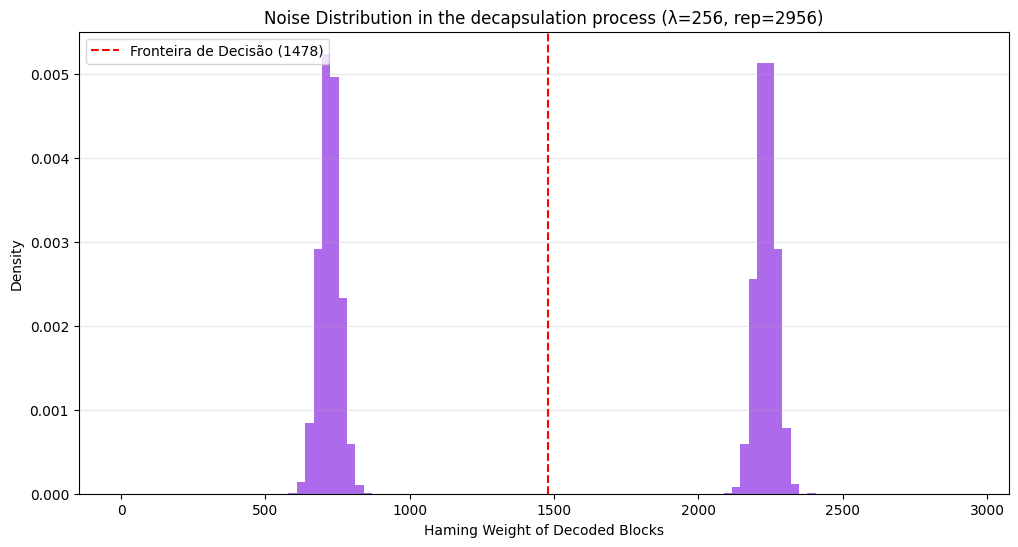

In [23]:
import matplotlib.pyplot as plt
import time
import secrets
import math
import hashlib
import gmpy2

# =============================================================================
# Distribuição de Densidade dos Pesos de Hamming (gmpy2 Otimizado)
# =============================================================================

def repetition_decode_with_weights_gmpy2(c_star_mpz, k, n):
    """Extrai os bits decifrados E os pesos de Hamming observados em cada bloco."""
    rep = n // k
    decoded = 0
    weights = []
    mask = (gmpy2.mpz(1) << rep) - gmpy2.mpz(1)
    
    for i in range(k):
        block = (c_star_mpz >> (i * rep)) & mask
        w = gmpy2.popcount(block)
        weights.append(w)
        if w > (rep // 2):
            decoded |= (1 << i)
    return decoded, weights

def run_simulation_gmpy2(iterations=50, lambda_sec=256, lambda_bit_string_size=256):
    print(f"Iniciando simulação: {iterations} iterações (gmpy2)...")
    t_start = time.time()
    
    pk_sim, sk_sim, n_sim, p_sim, h_sim = generate_keys(lambda_sec)
    rep_size = n_sim // lambda_sec
    all_observed_weights = []
    
    for i in range(iterations):
        # Usando as tuas funções otimizadas existentes
        (C1, C2), K = key_encapsulation(pk_sim, lambda_bit_string_size, n_sim, p_sim, h_sim)
        
        # Decapsulamento (Extração apenas para o gráfico)
        val_to_decode = ((sk_sim * C1) % p_sim) ^ C2
        _, weights = repetition_decode_with_weights_gmpy2(val_to_decode, lambda_bit_string_size, n_sim)
        
        all_observed_weights.extend(weights)
        
        if (i + 1) % 10 == 0:
            print(f"Progresso: {i + 1}/{iterations} ({time.time()-t_start:.1f}s)")

    return all_observed_weights, rep_size

# --- [Execução e Gráfico] ---
L_SEC_PLOT = 256
ITERACOES_PLOT = 50 
L_BIT_STRING_SIZE_PLOT = 256

pesos, rep_size = run_simulation_gmpy2(iterations=ITERACOES_PLOT, lambda_sec=L_SEC_PLOT, lambda_bit_string_size=L_BIT_STRING_SIZE_PLOT)

plt.figure(figsize=(12, 6))
# Dinamicamente ajusta as barras (bins) de acordo com o tamanho da repetição
plt.hist(pesos, bins=range(0, rep_size, max(1, rep_size//100)), density=True, color='blueviolet', alpha=0.7)

# Linha teórica do limite de decisão
plt.axvline(x=rep_size/2, color='red', linestyle='--', label=f'Fronteira de Decisão ({rep_size//2})')

plt.title(f"Noise Distribution in the decapsulation process (λ={L_SEC_PLOT}, rep={rep_size})")
plt.xlabel("Haming Weight of Decoded Blocks")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Given the distance of the code

In [24]:
import secrets
import math
import hashlib

def low_hamming_weight_number(n, h):
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def repetition_encode_with_rep(m_bits, rep, n):
    k = n // rep
    encoded = 0
    for i in range(k):
        bit = (m_bits >> i) & 1
        if bit:
            mask = ((1 << rep) - 1) << (i * rep)
            encoded |= mask
    return encoded

def repetition_decode_with_rep(c_star, rep, n):
    k = n // rep
    decoded = 0
    for i in range(k):
        block = (c_star >> (i * rep)) & ((1 << rep) - 1)
        if bin(block).count('1') > (rep // 2):
            decoded |= (1 << i)
    return decoded
# --- Core: Geração, Encapsulamento e Decapsulamento ---


def key_encapsulation_with_rep(pk, lambda_param, n, p, h, rep):
    # 1. Pick a uniformly random lambda-bit string K
    K = secrets.randbits(lambda_param)

    # 2. Let A = H1(K), B1 = H2(K), and B2 = H3(K)
    A = H1(K, n, h, lambda_param)
    B1 = H2(K, n, h, lambda_param)
    B2 = H3(K, n, h, lambda_param)
    
    # 3. C1 = A * R + B1; C2 = E(K) XOR (A * T + B2)
    C1 = (A * pk[0] + B1) % p
    encoded_K = repetition_encode_with_rep(K, rep, n)
    # Importante: o XOR ocorre após o mod p do termo (A*T + B2)
    C2 = encoded_K ^ ((A * pk[1] + B2) % p)
    
    return (C1, C2), K

def key_decapsulation_with_rep(C, sk_F, pk, lambda_param, n, p, h, rep):
    # 1. K' = D((F * C1) XOR C2)
    # F * C1 mod p cancela os termos de erro
    dec_val = ((sk_F * C[0]) % p) ^ C[1]
    K_prime = repetition_decode_with_rep(dec_val, rep, n)

    # 2. Re-deriva os parâmetros para verificação (A', B1', B2')
    A_prime = H1(K_prime, n, h, lambda_param)
    B1_prime = H2(K_prime, n, h, lambda_param)
    B2_prime = H3(K_prime, n, h, lambda_param)

    # 3. Reconstrói C' para verificar integridade
    C1_check = (A_prime * pk[0] + B1_prime) % p
    encoded_K_prime = repetition_encode_with_rep(K_prime, rep, n)
    C2_check = encoded_K_prime ^ ((A_prime * pk[1] + B2_prime) % p)

    # 4. Se C' == C, a chave é válida (Segurança IND-CCA)
    if C1_check == C[0] and C2_check == C[1]:
        return K_prime
    return None

# --- Execução do Teste ---

# Configurações
lambda_sec = 256 
rep=2048

lambda_bit_string_size = 16

# 1. Setup (Geração de Chaves)
pk, sk, n, p, h = generate_keys(lambda_sec)
print(f"--- Parâmetros --- \nn: {n}, h: {h}, p: Mersenne Prime")

# 2. Encapsulamento (Criação do Segredo)
(C1, C2), K_original = key_encapsulation_with_rep(pk, lambda_bit_string_size, n, p, h, rep)
print(f"\n--- Encapsulamento --- \nK original: {bin(K_original)}")

# 3. Decapsulamento (Recuperação do Segredo)
K_recuperado = key_decapsulation_with_rep((C1, C2), sk, pk, lambda_bit_string_size, n, p, h, rep)

# 4. Verificação final
if K_recuperado is not None:
    print(f"\n--- Sucesso! --- \nK recuperado: {bin(K_recuperado)}")
    print(f"As chaves coincidem? {K_original == K_recuperado}")
else:
    print("\n--- Erro! --- \nFalha na verificação de integridade.")

--- Parâmetros --- 
n: 756839, h: 256, p: Mersenne Prime

--- Encapsulamento --- 
K original: 0b110111111100110

--- Sucesso! --- 
K recuperado: 0b110111111100110
As chaves coincidem? True


Iniciando simulação: 1000 iterações (gmpy2)...
Parâmetros da simulação: n=756839, h=256, p=Mersenne Prime, rep=2048
Progresso: 10/1000 (21.5s)
Progresso: 20/1000 (44.3s)
Progresso: 30/1000 (65.3s)
Progresso: 40/1000 (89.2s)
Progresso: 50/1000 (115.4s)
Progresso: 60/1000 (141.6s)
Progresso: 70/1000 (169.6s)
Progresso: 80/1000 (196.5s)
Progresso: 90/1000 (224.2s)
Progresso: 100/1000 (251.3s)
Progresso: 110/1000 (278.1s)
Progresso: 120/1000 (305.4s)
Progresso: 130/1000 (332.0s)
Progresso: 140/1000 (359.1s)
Progresso: 150/1000 (385.8s)
Progresso: 160/1000 (412.6s)
Progresso: 170/1000 (439.5s)
Progresso: 180/1000 (466.3s)
Progresso: 190/1000 (492.8s)
Progresso: 200/1000 (519.3s)
Progresso: 210/1000 (546.1s)
Progresso: 220/1000 (572.6s)
Progresso: 230/1000 (599.3s)
Progresso: 240/1000 (625.7s)
Progresso: 250/1000 (652.2s)
Progresso: 260/1000 (678.8s)
Progresso: 270/1000 (705.3s)
Progresso: 280/1000 (731.8s)
Progresso: 290/1000 (758.2s)
Progresso: 300/1000 (784.8s)
Progresso: 310/1000 (811.3s

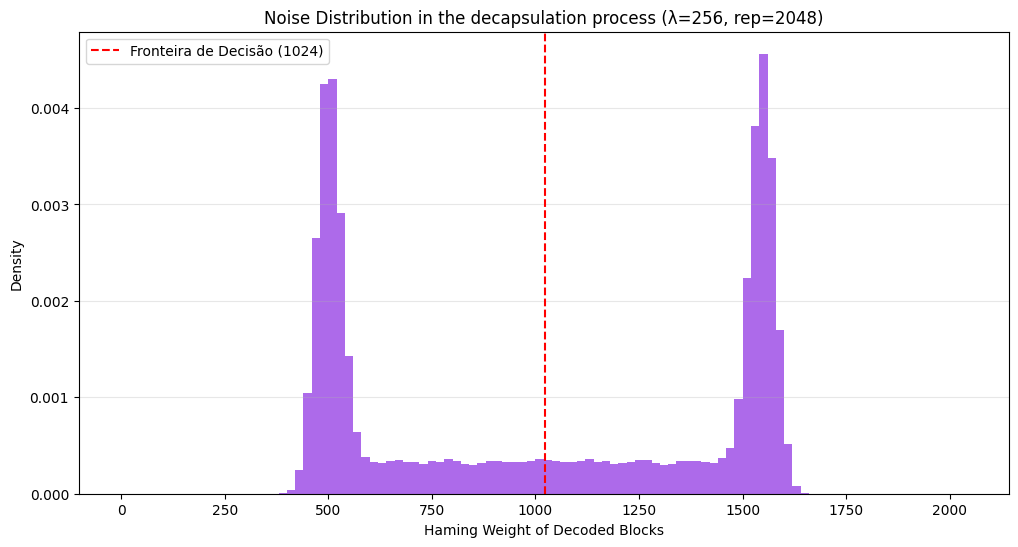

In [29]:
import matplotlib.pyplot as plt
import time
import secrets
import math
import hashlib
import gmpy2

# =============================================================================
# Distribuição de Densidade dos Pesos de Hamming (gmpy2 Otimizado)
# =============================================================================

def repetition_decode_with_weights_gmpy2_with_rep(c_star_mpz, k, n, rep):
    """Extrai os bits decifrados E os pesos de Hamming observados em cada bloco."""
    if (rep * k) > n:
        raise ValueError(f"Total encoded size ({rep * k}) exceeds n ({n}).")

    decoded = 0
    weights = []
    mask = (gmpy2.mpz(1) << rep) - gmpy2.mpz(1)
    
    for i in range(k):
        block = (c_star_mpz >> (i * rep)) & mask
        w = gmpy2.popcount(block)
        weights.append(w)
        if w > (rep // 2):
            decoded |= (1 << i)
    return decoded, weights

def run_simulation_gmpy2(iterations=50, lambda_sec=256, lambda_bit_string_size=256, rep_factor=2048):
    print(f"Iniciando simulação: {iterations} iterações (gmpy2)...")
    t_start = time.time()
    
    pk_sim, sk_sim, n_sim, p_sim, h_sim = generate_keys(lambda_sec)
    print(f"Parâmetros da simulação: n={n_sim}, h={h_sim}, p=Mersenne Prime, rep={rep_factor}")
    all_observed_weights = []

    if (rep_factor * lambda_bit_string_size) > n_sim:
        raise ValueError(f"Total encoded size ({rep_factor * lambda_bit_string_size}) exceeds n ({n_sim}).")
    
    
    for i in range(iterations):
        # Usando as tuas funções otimizadas existentes
        (C1, C2), K = key_encapsulation(pk_sim, lambda_bit_string_size, n_sim, p_sim, h_sim)
        
        # Decapsulamento (Extração apenas para o gráfico)
        val_to_decode = ((sk_sim * C1) % p_sim) ^ C2
        _, weights = repetition_decode_with_weights_gmpy2_with_rep(val_to_decode, lambda_bit_string_size, n_sim, rep_factor)
        
        all_observed_weights.extend(weights)
        
        if (i + 1) % 10 == 0:
            print(f"Progresso: {i + 1}/{iterations} ({time.time()-t_start:.1f}s)")

    return all_observed_weights

# --- [Execução e Gráfico] ---
L_SEC_PLOT = 256
ITERACOES_PLOT = 1000 
L_BIT_STRING_SIZE_PLOT = 256
REP_FACTOR_PLOT = 2048


pesos = run_simulation_gmpy2(iterations=ITERACOES_PLOT, lambda_sec=L_SEC_PLOT, lambda_bit_string_size=L_BIT_STRING_SIZE_PLOT, rep_factor=REP_FACTOR_PLOT)

plt.figure(figsize=(12, 6))
# Dinamicamente ajusta as barras (bins) de acordo com o tamanho da repetição
plt.hist(pesos, bins=range(0, REP_FACTOR_PLOT, max(1, REP_FACTOR_PLOT//100)), density=True, color='blueviolet', alpha=0.7)

# Linha teórica do limite de decisão
plt.axvline(x=REP_FACTOR_PLOT/2, color='red', linestyle='--', label=f'Fronteira de Decisão ({REP_FACTOR_PLOT//2})')

plt.title(f"Noise Distribution in the decapsulation process (λ={L_SEC_PLOT}, rep={REP_FACTOR_PLOT})")
plt.xlabel("Haming Weight of Decoded Blocks")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

#### transform into a publick key cryptosystem using a standard transformation

In [25]:
import secrets
import math
import hashlib

# ==========================================
# --- NOVA CAMADA: Public Key Encryption ---
# ==========================================

def encrypt_pke(pk, message, lambda_param, n, p, h):
    """
    Transformação Padrão: Transforma o KEM num PKE Híbrido.
    Suporta strings ou inteiros.
    """
    # 1. Executa o KEM para obter o texto cifrado da chave e o segredo K
    C_kem, K = key_encapsulation(pk, lambda_param, n, p, h)
    
    # 2. KDF: Deriva a chave simétrica estável usando SHA-256
    K_bytes = int(K).to_bytes((lambda_param + 7) // 8, 'big')
    sym_key = hashlib.sha256(K_bytes).digest()
    
    # Tratamento da mensagem de entrada (texto ou número)
    if isinstance(message, str):
        m_bytes = message.encode('utf-8')
    else:
        m_bytes = message.to_bytes((message.bit_length() + 7) // 8 or 1, 'big')
        
    # 3. Cifra de Fluxo: Expande a chave com SHAKE-256 e faz XOR com a mensagem
    stream = hashlib.shake_256(sym_key).digest(len(m_bytes))
    ciphertext_msg = bytes([b ^ s for b, s in zip(m_bytes, stream)])
    
    # O criptograma final contém o componente KEM e o componente Simétrico
    return C_kem, ciphertext_msg

def decrypt_pke(C_pke, sk_F, pk, lambda_param, n, p, h):
    """
    Decifra o criptograma híbrido recuperando primeiro o KEM.
    """
    C_kem, ciphertext_msg = C_pke
    
    # 1. Recupera o segredo K usando o decapsulamento do KEM
    K = key_decapsulation(C_kem, sk_F, pk, lambda_param, n, p, h)
    
    if K is None:
        raise ValueError("Falha de Integridade: O texto cifrado foi corrompido ou adulterado!")
        
    # 2. Reconstrói a mesma chave simétrica
    K_bytes = int(K).to_bytes((lambda_param + 7) // 8, 'big')
    sym_key = hashlib.sha256(K_bytes).digest()
    
    # 3. Gera o mesmo fluxo pseudoaleatório para reverter o XOR
    stream = hashlib.shake_256(sym_key).digest(len(ciphertext_msg))
    decrypted_bytes = bytes([b ^ s for b, s in zip(ciphertext_msg, stream)])
    
    return decrypted_bytes

# --- Execução do Teste PKE ---

lambda_sec = 256  # Size of the message in bits
lambda_bit_string_size = 256  # Size of the bit string in bits
pk, sk, n, p, h = generate_keys(lambda_sec)

print(f"--- Sistema PKE Híbrido Inicializado (Mersenne n={n}) ---")

# Mensagem Secreta Completa (String)
mensagem_original = "Mensagem ultra secreta pós-quântica baseada em Mersenne!"
print(f"\nMensagem Original: '{mensagem_original}'")

# 1. Encriptação de Chave Pública (PKE)
C_final = encrypt_pke(pk, mensagem_original, lambda_bit_string_size, n, p, h)
print(f"Texto Cifrado Simétrico (hex): {C_final[1].hex()[:30]}...")

# 2. Decifração de Chave Pública (PKE)
dados_recuperados = decrypt_pke(C_final, sk, pk, lambda_bit_string_size, n, p, h)
mensagem_recuperada = dados_recuperados.decode('utf-8')

print(f"\nMensagem Recuperada: '{mensagem_recuperada}'")
print(f"Sucesso Total do PKE? {mensagem_original == mensagem_recuperada}")

--- Sistema PKE Híbrido Inicializado (Mersenne n=756839) ---

Mensagem Original: 'Mensagem ultra secreta pós-quântica baseada em Mersenne!'
Texto Cifrado Simétrico (hex): 521bde439505e6b224ac348caa0fb8...

Mensagem Recuperada: 'Mensagem ultra secreta pós-quântica baseada em Mersenne!'
Sucesso Total do PKE? True


### Encapsulation Method with Reed Muller

In [26]:
import secrets
import math
import hashlib
import numpy as np
import gmpy2
from math import comb

def get_points(m):
    if m == 0:
        return [()]
    sub = get_points(m - 1)
    return [p + (0,) for p in sub] + [p + (1,) for p in sub]

def generator_matrix(m):
    """Matriz geradora de RM(m,1)."""
    r = 1
    points = get_points(m)
    n = 2 ** m
    # Monómios: [constante, x0, x1, ..., x_{m-1}]
    monomials = [[]] + [[i] for i in range(m)]
    k = len(monomials)  # = m+1
    G = np.zeros((k, n), dtype=np.uint8)
    for i, mono in enumerate(monomials):
        for j, point in enumerate(points):
            val = 1
            for idx in mono:
                val *= point[idx]
            G[i][j] = val % 2
    return G

def encode(message_bits, G):
    """Array numpy de k bits → inteiro (codeword de n=2^m bits)."""
    cw = np.dot(message_bits, G) % 2
    result = 0
    for i, b in enumerate(cw):
        if int(b):
            result |= (1 << i)
    return result

def majority_decode(received_int, m):
    """
    Decoder por voto maioritário para RM(m,1).
    Recebe um inteiro (codeword de 2^m bits com possíveis erros).
    Devolve lista de m+1 bits [a0, a1, ..., am].
    Corrige até 2^(m-2)-1 erros.
    """
    n = 2 ** m
    points = get_points(m)
    point_to_idx = {p: i for i, p in enumerate(points)}

    # Converte inteiro para lista de bits
    r_arr = [(received_int >> i) & 1 for i in range(n)]

    coefficients = [0] * (m + 1)  # [a0, a1, ..., am]

    # Recupera a1, ..., am por voto maioritário em pares
    for var in range(m):
        v1, v0 = 0, 0
        for idx, p in enumerate(points):
            if p[var] == 1:
                p_comp = list(p)
                p_comp[var] = 0
                idx_comp = point_to_idx[tuple(p_comp)]
                if r_arr[idx] ^ r_arr[idx_comp]:
                    v1 += 1
                else:
                    v0 += 1
        coefficients[var + 1] = 1 if v1 > v0 else 0

    # Recupera a0 usando os coeficientes já encontrados
    v1, v0 = 0, 0
    for idx, p in enumerate(points):
        contrib = 0
        for var in range(m):
            contrib ^= coefficients[var + 1] * p[var]
        if r_arr[idx] ^ contrib:
            v1 += 1
        else:
            v0 += 1
    coefficients[0] = 1 if v1 > v0 else 0

    return coefficients


# =================== Mersenne KEM ===================

def low_hamming_weight_number(n, h):
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def get_mersenne_exponent(min_n):
    """Menor Mersenne exponent >= min_n."""
    mersenne_exponents = [31, 61, 127, 521, 607, 1279, 2203, 2281,
                          3217, 4253, 4423, 9689, 9941, 11213, 19937,
                          21701, 86243, 216091, 756839]
    for n in mersenne_exponents:
        if n >= min_n:
            return n
    return min_n

def generate_keys(lambda_param):
    """
    lambda_param bits de segurança.
    Usa RM(m,1) com m = lambda_param - 1
      → k = m+1 = lambda_param bits de mensagem
      → n_cw = 2^m bits de codeword
    n_mersenne = maior entre 10*h^2 e n_cw.
    """
    h = lambda_param
    m = lambda_param - 1       # m tal que k = m+1 = lambda_param
    n_cw = 2 ** m              # tamanho da codeword

    # n_mersenne tem de ser >= n_cw E >= 10*h^2
    n_min = max(10 * h ** 2, n_cw)
    n_mers = get_mersenne_exponent(n_min)

    p = (1 << n_mers) - 1
    F     = low_hamming_weight_number(n_mers, h)
    G_key = low_hamming_weight_number(n_mers, h)
    R     = secrets.randbits(n_mers)
    T     = (F * R + G_key) % p

    d = 2 ** (m - 1)  # distância mínima RM(m,1)
    print(f"Parametros:")
    print(f"  lambda_param={lambda_param}, h={h}")
    print(f"  n_mersenne={n_mers} (p tem {n_mers} bits)")
    print(f"  RM({m},1): k={m+1}, n_cw={n_cw}, corrige até {(d-1)//2} erros")
    print(f"  Ruido estimado: ~{2*h**2} bits  <<  {(d-1)//2} OK")

    return (R, T), F, n_mers, p, h, m, n_cw


def decrypt(C, sk_F, p, m):
    C1, C2 = C
    noisy_m = ((sk_F * C1) % p) ^ C2
    return majority_decode(noisy_m, m)


def expandable_hash_to_hamming(seed_int, n, h, lambda_param, salt=b''):
    # Converte o inteiro K para bytes para o Hash
    if isinstance(seed_int, np.ndarray):
        seed_int = int(sum(int(b) << i for i, b in enumerate(seed_int)))
    seed_bytes = seed_int.to_bytes((lambda_param + 7) // 8, 'big')
    xo_function = hashlib.shake_256(seed_bytes + salt)
    
    indices = set()
    byte_counter = 0
    while len(indices) < h:
        bytes_needed = (n.bit_length() + 7) // 8
        raw_bytes = xo_function.digest(byte_counter + bytes_needed)[byte_counter:]
        idx = int.from_bytes(raw_bytes, 'big') % n
        indices.add(idx)
        byte_counter += bytes_needed
        
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def H1(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H1')
def H2(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H2')
def H3(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H3')

def encrypt_encaps(pk, encoded_m, n, p, h, K):
    R, T = pk
    A  = H1(K, n, h, lambda_param)
    B1 = H2(K, n, h, lambda_param)
    B2 = H3(K, n, h, lambda_param)
    C1 = (A * R + B1) % p
    
    # ← mask aqui também!
    mask = (1 << encoded_m.bit_length()) - 1  # ou (1 << n_cw) - 1
    C2 = ((A * T + B2) % p & mask) ^ encoded_m
    
    return (C1, C2), K


def decrypt_encaps(pk, sk, C, p, m, G):
    C1, C2 = C
    mask = (1 << 2**m) - 1
    
    noisy_m = ((sk * C1) % p & mask) ^ C2  # mask aqui também
    
    Kprime_bits = majority_decode(noisy_m, m)
    Kprime = sum(b << i for i, b in enumerate(Kprime_bits))

    A  = H1(Kprime, n, h, lambda_param)
    B1 = H2(Kprime, n, h, lambda_param)
    B2 = H3(Kprime, n, h, lambda_param)

    R, T = pk
    C1_check = (A * R + B1) % p
    encoded_check = encode(np.array(Kprime_bits), G)

    # mask igual ao do encrypt
    C2_check = ((A * T + B2) % p & mask) ^ encoded_check

    if C1_check == C[0] and C2_check == C[1]:
        return Kprime
    return None

lambda_param = 16

pk, sk, n, p, h, m, n_cw = generate_keys(lambda_param)
G = generator_matrix(m)
k = m + 1
K_bits = np.random.randint(0, 2, size=k)
K_int = int(sum(int(b) << i for i, b in enumerate(K_bits)))

encoded_k = encode(K_bits, G)   # encode recebe array
C, K = encrypt_encaps(pk, encoded_k, n, p, h, K_int)  # H1 recebe inteiro
Kprime = decrypt_encaps(pk,sk,C,p,m,G)
print(Kprime)


# 4. Verificação final
if Kprime is not None:
    print(f"\n--- Sucesso! --- \nK recuperado: {bin(Kprime)}")
    print(f"As chaves coincidem? {K_int == Kprime}")
else:
    print("\n--- Erro! --- \nFalha na verificação de integridade.")



Parametros:
  lambda_param=16, h=16
  n_mersenne=86243 (p tem 86243 bits)
  RM(15,1): k=16, n_cw=32768, corrige até 8191 erros
  Ruido estimado: ~512 bits  <<  8191 OK
10012

--- Sucesso! --- 
K recuperado: 0b10011100011100
As chaves coincidem? True


#### Transform into a public Key cryptosystem using ReedMuller and Standard Transformation

In [27]:
import secrets
import math
import hashlib

# ==========================================
# --- NOVA CAMADA: Public Key Encryption ---
# ==========================================

def encrypt_pke(message, lambda_param):
    """
    Transformação Padrão: Transforma o KEM num PKE Híbrido.
    Suporta strings ou inteiros.
    """
    # 1. Executa o KEM para obter o texto cifrado da chave e o segredo K
    pk, sk, n, p, h, m, n_cw = generate_keys(lambda_param)
    G = generator_matrix(m)
    k = m + 1
    K_bits = np.random.randint(0, 2, size=k)
    K_int = int(sum(int(b) << i for i, b in enumerate(K_bits)))

    encoded_k = encode(K_bits, G)   # encode recebe array
    C, K = encrypt_encaps(pk, encoded_k, n, p, h, K_int)  # H1 recebe inteiro
        
    # 2. KDF: Deriva a chave simétrica estável usando SHA-256
    K_bytes = int(K).to_bytes((lambda_param + 7) // 8, 'big')
    sym_key = hashlib.sha256(K_bytes).digest()
    
    # Tratamento da mensagem de entrada (texto ou número)
    if isinstance(message, str):
        m_bytes = message.encode('utf-8')
    else:
        m_bytes = message.to_bytes((message.bit_length() + 7) // 8 or 1, 'big')
        
    # 3. Cifra de Fluxo: Expande a chave com SHAKE-256 e faz XOR com a mensagem
    stream = hashlib.shake_256(sym_key).digest(len(m_bytes))
    ciphertext_msg = bytes([b ^ s for b, s in zip(m_bytes, stream)])
    
    # O criptograma final contém o componente KEM e o componente Simétrico
    return pk, sk, C, ciphertext_msg, G, m, n, p, h

def decrypt_pke(C, ciphertext_msg, sk, pk, lambda_param, G, n, p, h, m):
    """
    Decifra o criptograma híbrido recuperando primeiro o KEM.
    """

    # 1. Recupera o segredo K usando o decapsulamento do KEM
    Kprime = decrypt_encaps(pk,sk,C,p,m,G)
    
    if Kprime is None:
        raise ValueError("Falha de Integridade: O texto cifrado foi corrompido ou adulterado!")
        
    # 2. Reconstrói a mesma chave simétrica
    K_bytes = int(Kprime).to_bytes((lambda_param + 7) // 8, 'big')
    sym_key = hashlib.sha256(K_bytes).digest()
    
    # 3. Gera o mesmo fluxo pseudoaleatório para reverter o XOR
    stream = hashlib.shake_256(sym_key).digest(len(ciphertext_msg))
    decrypted_bytes = bytes([b ^ s for b, s in zip(ciphertext_msg, stream)])
    
    return decrypted_bytes

# --- Execução do Teste PKE ---

lambda_sec = 16  # Size of the message in bits

print(f"--- Sistema PKE Híbrido Inicializado (Mersenne n={n}) ---")



# Mensagem Secreta Completa (String)
mensagem_original = "Mensagem ultra secreta pós-quântica baseada em Mersenne!"
print(f"\nMensagem Original: '{mensagem_original}'")

# 1. Encriptação de Chave Pública (PKE)
pk, sk, C, ciphertext_msg, G, m, n, p, h = encrypt_pke(mensagem_original, lambda_sec)
print(f"Texto Cifrado Simétrico (hex): {ciphertext_msg.hex()[:30]}...")

# 2. Decifração de Chave Pública (PKE)
dados_recuperados = decrypt_pke(C, ciphertext_msg, sk, pk, lambda_sec, G, n, p, h, m)
mensagem_recuperada = dados_recuperados.decode('utf-8')

print(f"\nMensagem Recuperada: '{mensagem_recuperada}'")
print(f"Sucesso Total do PKE? {mensagem_original == mensagem_recuperada}")

--- Sistema PKE Híbrido Inicializado (Mersenne n=86243) ---

Mensagem Original: 'Mensagem ultra secreta pós-quântica baseada em Mersenne!'
Parametros:
  lambda_param=16, h=16
  n_mersenne=86243 (p tem 86243 bits)
  RM(15,1): k=16, n_cw=32768, corrige até 8191 erros
  Ruido estimado: ~512 bits  <<  8191 OK
Texto Cifrado Simétrico (hex): f7b138f0db49fbaf569fa99b57ff76...

Mensagem Recuperada: 'Mensagem ultra secreta pós-quântica baseada em Mersenne!'
Sucesso Total do PKE? True


In [ ]:
def encode_int(k_int, m):
    """Converte inteiro k_int (m+1 bits de mensagem) → codeword RM(m,1) como inteiro."""
    G = generator_matrix(m)          # k×n_cw matrix, já definida anteriormente
    msg_bits = np.array([(k_int >> i) & 1 for i in range(m + 1)], dtype=int)
    cw_bits  = (msg_bits @ G) % 2
    result   = 0
    for i, b in enumerate(cw_bits):
        result |= (int(b) << i)
    return result

## Análise de Segurança

### Pressuposto de Segurança

O **Pressuposto da Combinação de Baixo Peso de Hamming de Mersenne (MLHC)** estabelece que:  
Dados $(R, F \cdot R + G \bmod p)$ com $F, G$ de peso de Hamming $h$, nenhum adversário PPT (Tempo Polinomial Probabilístico) o consegue distinguir de $(R, U)$ onde $U$ é uniformemente aleatório.

### Resumo dos Ataques Conhecidos

| Ataque | Complexidade Clássica | Complexidade Quântica | Notas |
|--------|---------------------|--------------------|-------|
| Força bruta ingénua | $\binom{n}{h}$ | $\binom{n}{h}^{1/2}$ (Grover) | Inviável para um $h$ grande |
| Baseado em LLL (BCGN17) | $O(2^{2h})$ | $O(2^h)$ (com Grover) | Motiva a definição de $h=\lambda$ |
| Meet-in-the-middle (dBDJdW17) | $O\!\left(\binom{n-1}{h-1}^{1/2}\right)$ | $O\!\left(\binom{n-1}{h-1}^{1/3}\right)$ | Superior a $2^h$ para os nossos parâmetros |
| Chave fraca (BCGN17) | Polinomial se $F, G < \sqrt{p}$ | — | Evitado pela geração de chaves aleatórias |

### Recomendações de Parâmetros

Definir $h = \lambda$ (parâmetro de segurança) garante que mesmo o ataque LLL acelerado por Grover tenha um custo de $\Omega(2^h) = \Omega(2^\lambda)$.
---

In [28]:


import math
import secrets

# Redefinimos localmente para garantir que funciona mesmo se a célula for corrida isoladamente
def hamming_weight(x):
    return bin(int(x)).count('1')

def log2_binomial(n, k):
    """Calcula log2(C(n, k)) """
    if k < 0 or k > n:
        return float('-inf')
    if k == 0 or k == n:
        return 0.0
    return sum(math.log2(n - i) - math.log2(i + 1) for i in range(k))


print("\n" + "=" * 60)
print("Teste de Distribuição do Peso de Hamming (Verificação de Pseudo-aleatoriedade)")
print("=" * 60)
print("\nA verificar se T = F*R+G se assemelha a uma string aleatória uniforme...")

# Utilizar um n médio para o teste estatístico
n_stat, h_stat = 127, 5
p_stat = 2**n_stat - 1
SAMPLES = 500

hw_T = []
hw_U = []
for _ in range(SAMPLES):
    F_s = low_hamming_weight_number(n_stat, h_stat)
    G_s = low_hamming_weight_number(n_stat, h_stat)
    R_s = secrets.randbits(n_stat)
    T_s = (F_s * R_s + G_s) % p_stat
    hw_T.append(hamming_weight(T_s))
    hw_U.append(hamming_weight(secrets.randbits(n_stat)))

mean_T = sum(hw_T) / SAMPLES
mean_U = sum(hw_U) / SAMPLES
var_T  = sum((x - mean_T)**2 for x in hw_T) / SAMPLES
var_U  = sum((x - mean_U)**2 for x in hw_U) / SAMPLES
expected_mean = n_stat / 2
expected_var  = n_stat / 4

print(f"  (n={n_stat}, h={h_stat}, {SAMPLES} amostras)")
print(f"  {'Estatística':<25} {'T=F*R+G':>10} {'Uniforme':>10} {'Esperado':>10}")
print(f"  {'Média do Peso de Ham.':<25} {mean_T:>10.2f} {mean_U:>10.2f} {expected_mean:>10.1f}")
print(f"  {'Variância do Peso Ham.':<25} {var_T:>10.2f} {var_U:>10.2f} {expected_var:>10.1f}")
print(f"\n  As distribuições parecem semelhantes: {abs(mean_T - mean_U) < 2}")


Teste de Distribuição do Peso de Hamming (Verificação de Pseudo-aleatoriedade)

A verificar se T = F*R+G se assemelha a uma string aleatória uniforme...
  (n=127, h=5, 500 amostras)
  Estatística                  T=F*R+G   Uniforme   Esperado
  Média do Peso de Ham.          63.72      63.25       63.5
  Variância do Peso Ham.         35.25      33.60       31.8

  As distribuições parecem semelhantes: ✓


## Comparação do Reed Muller com o Repetition code

Helper functions loaded.


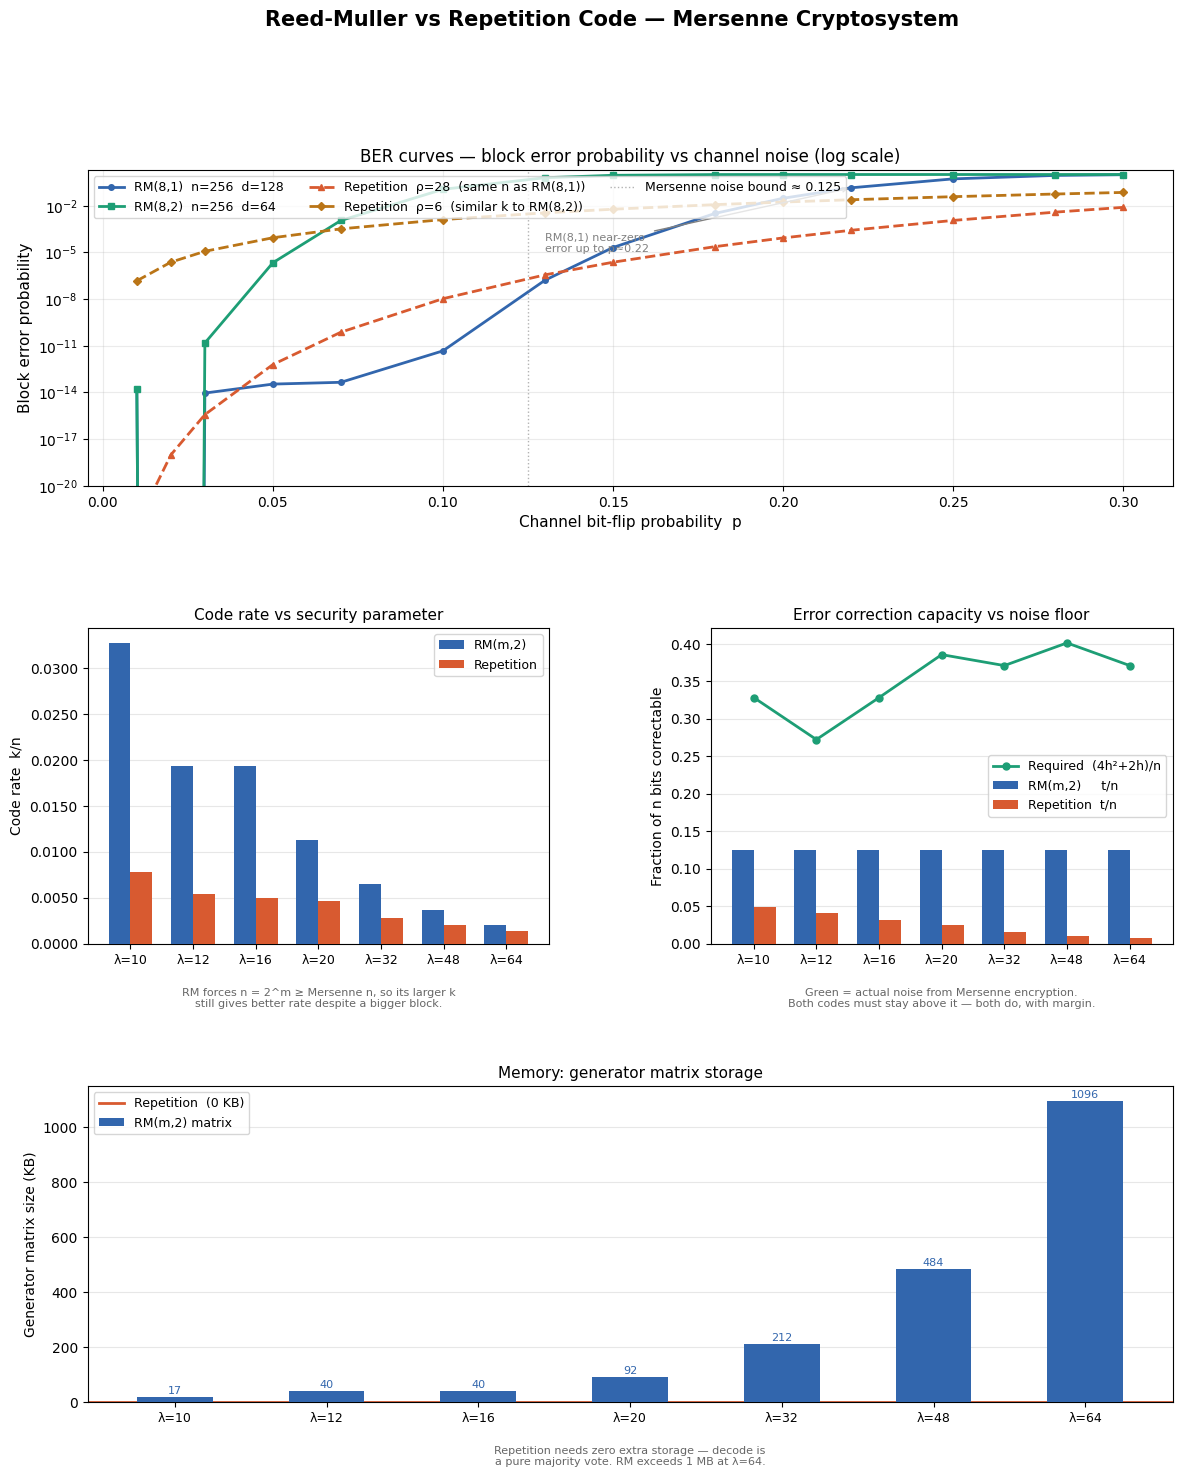

Figure saved as ecc_comparison.png

Summary table — paper parameters  λ = h = 256

  Metric                                Repetition        RM(22,2)
  --------------------------------  --------------  --------------
  n (codeword length)                      756,839       4,194,304
  k (message bits)                             256             254
  Code rate  k/n                          0.000338        0.000061
  Min distance  d                            ≈2956       1,048,576
  Errors correctable  t                      1,478         524,287
  t/n  (correction fraction)               0.00195         0.12500
  Noise floor (4h²+2h)/n                   0.34704         0.34704
  Generator matrix                            0 KB          127 MB
  Encode complexity                           O(k)          O(k·n)
  Decode complexity                           O(n)          O(n·m)
  δ (decryption failure)                  < 2^-239        < 2^-128

  Both codes satisfy the noise requirement (t

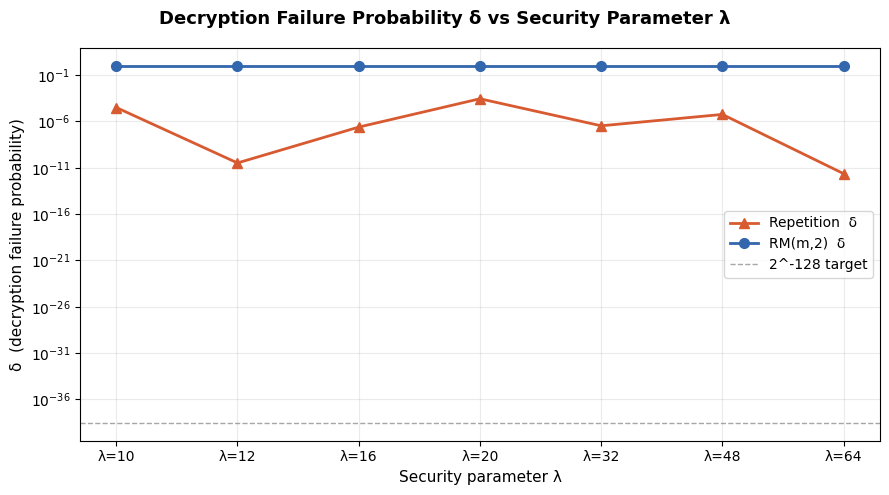

Figure saved as delta_vs_lambda.png


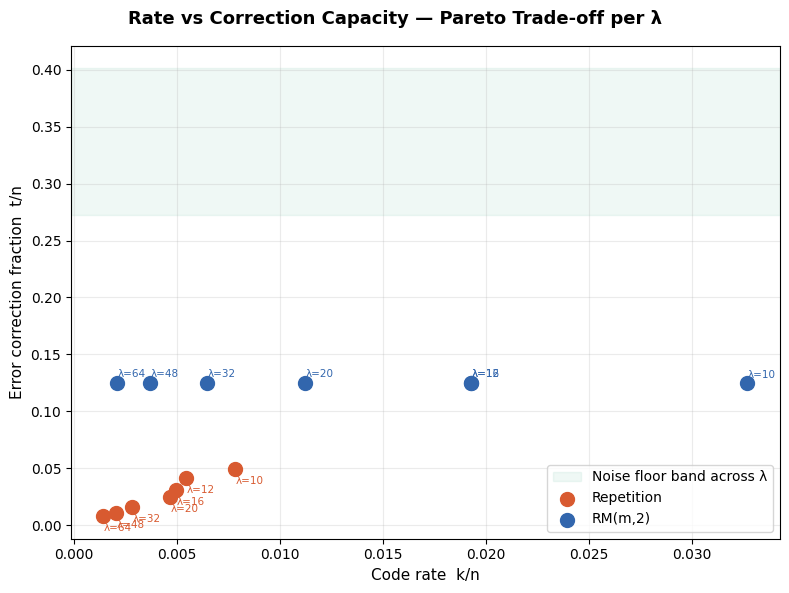

Figure saved as pareto_scatter.png
  SECÇÃO 6 — Análise Empírica de Segurança

[1/4] Distribuição real do ruído (λ=12, 300 ensaios)...
Parametros:
  lambda_param=12, h=12
  n_mersenne=2203 (p tem 2203 bits)
  RM(11,1): k=12, n_cw=2048, corrige até 511 erros
  Ruido estimado: ~288 bits  <<  511 OK


ValueError: too many values to unpack (expected 5)

In [29]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from math import comb, log2, floor, ceil
%matplotlib inline

def rep_ber(p, rho):
    """
    Probabilidade de falha da descodificação por voto da maioria para um bit de mensagem,
    quando o bloco de repetição tem comprimento rho e a probabilidade de inversão de bit
    no canal é p.
    P(X > rho/2), em que X ~ Bin(rho, p).
    """
    t = rho // 2
    total = 0.0
    for i in range(t + 1, rho + 1):
        total += comb(rho, i) * (p ** i) * ((1 - p) ** (rho - i))
    return max(total, 1e-320)


def rm_ber(p, n, d):
    """
    Probabilidade de erro de bloco para um código RM com distância mínima d,
    sob descodificação por distância limitada (corrige t = floor((d-1)/2) erros).
    P(mais do que t erros em n bits) = 1 - CDF binomial em t.
    Usa soma em espaço logarítmico para evitar overflow para n grandes.
    """
    from math import lgamma, log, exp
    if p == 0:
        return 0.0
    if p == 1:
        return 1.0 if n > d - 1 else 0.0

    t = (d - 1) // 2
    log_p  = log(p)
    log_1p = log(1 - p)

    # log C(n, i) = lgamma(n+1) - lgamma(i+1) - lgamma(n-i+1)
    log_n_fact = lgamma(n + 1)
    log_ok_terms = []
    for i in range(t + 1):
        log_binom = log_n_fact - lgamma(i + 1) - lgamma(n - i + 1)
        log_term  = log_binom + i * log_p + (n - i) * log_1p
        log_ok_terms.append(log_term)

    # soma estável em log-sum-exp
    max_log = max(log_ok_terms)
    ok = exp(max_log) * sum(exp(lt - max_log) for lt in log_ok_terms)
    return max(1.0 - ok, 1e-320)


# Expoentes dos primos de Mersenne p para cada lambda  (10·h² < p ≤ 16·h²)
MERSENNE_N = {10: 1279, 12: 2203, 16: 3217, 20: 4253, 32: 11213, 48: 23209, 64: 44497}

def rm_params(n_mersenne, r=2):
    """
    Para RM(m, r), com m = ceil(log2(n_mersenne)):
    devolve (m, n=2^m, k=soma C(m,i) para i<=r, d=2^(m-r))
    """
    m = ceil(log2(n_mersenne))
    n = 2 ** m
    k = sum(comb(m, i) for i in range(r + 1))
    d = 2 ** (m - r)
    return m, n, k, d


print("Funções auxiliares carregadas.")


BLUE   = '#3266ad'
BLUE_L = '#85B7EB'
RED    = '#D85A30'
RED_L  = '#F0997B'
GREEN  = '#1D9E75'
AMBER  = '#BA7517'

fig = plt.figure(figsize=(14, 16))
fig.suptitle(
    "Reed-Muller vs Código de Repetição — Criptossistema de Mersenne",
    fontsize=15, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)


# Curvas BER (Block Error)

ax1 = fig.add_subplot(gs[0, :])

ps = np.array([0.01, 0.02, 0.03, 0.05, 0.07, 0.10,
               0.13, 0.15, 0.18, 0.20, 0.22, 0.25, 0.28, 0.30])

ax1.semilogy(ps, [rm_ber(p, 256, 128) for p in ps],
             color=BLUE,  lw=2, marker='o', ms=4, label='RM(8,1)  n=256  d=128')
ax1.semilogy(ps, [rm_ber(p, 256,  64) for p in ps],
             color=GREEN, lw=2, marker='s', ms=4, label='RM(8,2)  n=256  d=64')
ax1.semilogy(ps, [rep_ber(p, 28) for p in ps],
             color=RED,   lw=2, marker='^', ms=4, ls='--',
             label='Repetição  ρ=28  (mesmo n que RM(8,1))')
ax1.semilogy(ps, [rep_ber(p,  6) for p in ps],
             color=AMBER, lw=2, marker='D', ms=4, ls='--',
             label='Repetição  ρ=6  (k semelhante a RM(8,2))')
ax1.axvline(0.125, color='gray', lw=1, ls=':', alpha=0.6,
            label='Limite de ruído de Mersenne ≈ 0.125')
ax1.set_xlabel("Probabilidade de inversão de bit do canal  p", fontsize=11)
ax1.set_ylabel("Probabilidade de erro de bloco", fontsize=11)
ax1.set_title("Curvas BER — probabilidade de erro de bloco vs ruído do canal (escala log)", fontsize=12)
ax1.legend(fontsize=9, ncol=3, loc='upper left')
ax1.set_ylim(1e-20, 2)
ax1.grid(True, which='both', alpha=0.25)
ax1.annotate(
    "RM(8,1) com erro quase nulo\naté p≈0.22",
    xy=(0.22, rm_ber(0.22, 256, 128)),
    xytext=(0.13, 1e-5),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=8, color='gray'
)


# Análise da taxa de código

ax2 = fig.add_subplot(gs[1, 0])

lams = [10, 12, 16, 20, 32, 48, 64]
x    = np.arange(len(lams))
w    = 0.35

rep_rates = [lam / MERSENNE_N[lam] for lam in lams]
rm_rates  = [rm_params(MERSENNE_N[lam])[2] / rm_params(MERSENNE_N[lam])[1] for lam in lams]

ax2.bar(x - w/2, rm_rates,  w, color=BLUE, label='RM(m,2)',    zorder=3)
ax2.bar(x + w/2, rep_rates, w, color=RED,  label='Repetição', zorder=3)
ax2.set_xticks(x)
ax2.set_xticklabels([f'λ={l}' for l in lams], fontsize=9)
ax2.set_ylabel("Taxa de código  k/n", fontsize=10)
ax2.set_title("Taxa de código vs parâmetro de segurança", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3, zorder=0)
ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
ax2.text(0.5, -0.20,
    "RM força n = 2^m ≥ n de Mersenne, por isso o k maior\ncontinua a dar melhor taxa apesar de um bloco maior.",
    transform=ax2.transAxes, ha='center', fontsize=8, color='#666')


# Comparação da capacidade de correção de erros

ax3 = fig.add_subplot(gs[1, 1])

rep_corr  = [floor(floor(MERSENNE_N[l] / l) / 2) / MERSENNE_N[l] for l in lams]
rm_corr   = [floor((rm_params(MERSENNE_N[l])[3] - 1) / 2) / rm_params(MERSENNE_N[l])[1] for l in lams]
noise_req = [(4*l*l + 2*l) / MERSENNE_N[l] for l in lams]

ax3.bar(x - w/2, rm_corr,  w, color=BLUE, label='RM(m,2)     t/n', zorder=3)
ax3.bar(x + w/2, rep_corr, w, color=RED,  label='Repetição  t/n', zorder=3)
ax3.plot(x, noise_req, color=GREEN, lw=2, marker='o', ms=5, zorder=4,
         label='Necessário  (4h²+2h)/n')
ax3.set_xticks(x)
ax3.set_xticklabels([f'λ={l}' for l in lams], fontsize=9)
ax3.set_ylabel("Fração de n bits corrigível", fontsize=10)
ax3.set_title("Capacidade de correção de erros vs piso de ruído", fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3, zorder=0)
ax3.text(0.5, -0.20,
    "Verde = ruído real da encriptação de Mersenne.\n"
    "Ambos os códigos têm de ficar acima disso — e ficam, com margem.",
    transform=ax3.transAxes, ha='center', fontsize=8, color='#666')


# Subgráfico 4: uso de memória

ax5 = fig.add_subplot(gs[2, :])

rm_mem_kb = [rm_params(MERSENNE_N[l])[2] * rm_params(MERSENNE_N[l])[1] / 8 / 1024 for l in lams]

bars = ax5.bar(x, rm_mem_kb, color=BLUE, label='Matriz RM(m,2)', zorder=3, width=0.5)
for bar, val in zip(bars, rm_mem_kb):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rm_mem_kb)*0.01,
             f'{val:.0f}', ha='center', fontsize=8, color=BLUE)
ax5.axhline(0, color=RED, lw=2, label='Repetição  (0 KB)')
ax5.set_xticks(x)
ax5.set_xticklabels([f'λ={l}' for l in lams], fontsize=9)
ax5.set_ylabel("Tamanho da matriz geradora (KB)", fontsize=10)
ax5.set_title("Memória: armazenamento da matriz geradora", fontsize=11)
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3, zorder=0)
ax5.text(0.5, -0.20,
    "Repetição não precisa de armazenamento extra — a descodificação é\n"
    "uma votação por maioria pura. RM ultrapassa 1 MB em λ=64.",
    transform=ax5.transAxes, ha='center', fontsize=8, color='#666')


plt.savefig("ecc_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como ecc_comparison.png")


# Tabela resumo

print("\n" + "=" * 78)
print("Tabela resumo — parâmetros do artigo  λ = h = 256")
print("=" * 78)

lam = 256
n_rep  = 756839
rho    = n_rep // lam
t_rep  = rho // 2
noise  = (4 * lam**2 + 2 * lam) / n_rep

# O artigo usa explicitamente RM(22,2): n=2^22=4194304, k=254, d=2^20
m_rm, n_rm, k_rm, d_rm = 22, 2**22, 254, 2**20
t_rm   = (d_rm - 1) // 2
mem_rm = k_rm * n_rm / 8 / 1024 / 1024  # MB

rows = [
    ("n (comprimento do codeword)", f"{n_rep:>12,}",         f"{n_rm:>12,}"),
    ("k (bits da mensagem)",        f"{lam:>12}",            f"{k_rm:>12}"),
    ("Taxa de código  k/n",         f"{lam/n_rep:>12.6f}",   f"{k_rm/n_rm:>12.6f}"),
    ("Distância mínima  d",         f"{'≈'+str(rho):>12}",   f"{d_rm:>12,}"),
    ("Erros corrigíveis  t",        f"{t_rep:>12,}",         f"{t_rm:>12,}"),
    ("t/n  (fração corrigível)",    f"{t_rep/n_rep:>12.5f}", f"{t_rm/n_rm:>12.5f}"),
    ("Piso de ruído (4h²+2h)/n",    f"{noise:>12.5f}",       f"{noise:>12.5f}"),
    ("Matriz geradora",             f"{'0 KB':>12}",         f"{mem_rm:>11.0f} MB"),
    ("Complexidade de codificação",  f"{'O(k)':>12}",         f"{'O(k·n)':>12}"),
    ("Complexidade de descodificação", f"{'O(n)':>12}",       f"{'O(n·m)':>12}"),
    ("δ (falha de decriptação)",    f"{'< 2^-239':>12}",     f"{'< 2^-128':>12}"),
]

print(f"\n  {'Métrica':<32}  {'Repetição':>14}  {'RM(22,2)':>14}")
print(f"  {'-'*32}  {'-'*14}  {'-'*14}")
for label, rep_val, rm_val in rows:
    print(f"  {label:<32}  {rep_val:>14}  {rm_val:>14}")

print()
print("  Ambos os códigos cumprem o requisito de ruído (t/n > piso de ruído).")
print("  A secção 8.1 do artigo usa RM para provas rigorosas; a secção 8.2 usa Repetição")
print("  com análise heurística — a escolha prática recomendada.")


# δ ≈ BER avaliada no piso de ruído de Mersenne p = (4h²+2h)/n para cada λ.
# Esta é a probabilidade de falha de decriptação de um único bloco para cada esquema.

fig2, ax = plt.subplots(figsize=(9, 5))
fig2.suptitle("Probabilidade de Falha de Decriptação δ vs Parâmetro de Segurança λ",
              fontsize=13, fontweight='bold')

lams_ext = [10, 12, 16, 20, 32, 48, 64]
delta_rep = []
delta_rm  = []

for l in lams_ext:
    n_m     = MERSENNE_N[l]
    p_noise = (4*l*l + 2*l) / n_m

    rho_l = n_m // l
    delta_rep.append(rep_ber(p_noise, rho_l))

    _, n_rm_l, _, d_rm_l = rm_params(n_m, r=2)
    delta_rm.append(rm_ber(p_noise, n_rm_l, d_rm_l))

x_ext = np.arange(len(lams_ext))
ax.semilogy(x_ext, delta_rep, color=RED,  lw=2, marker='^', ms=7, label='Repetição  δ')
ax.semilogy(x_ext, delta_rm,  color=BLUE, lw=2, marker='o', ms=7, label='RM(m,2)  δ')
ax.axhline(2**-128, color='gray', lw=1, ls='--', alpha=0.7, label='Objetivo 2^-128')

ax.set_xticks(x_ext)
ax.set_xticklabels([f'λ={l}' for l in lams_ext])
ax.set_ylabel("δ  (probabilidade de falha de decriptação)", fontsize=11)
ax.set_xlabel("Parâmetro de segurança λ", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.25)

plt.tight_layout()
plt.savefig("delta_vs_lambda.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como delta_vs_lambda.png")


# Cada par (λ, esquema) é um ponto no plano (taxa de código, t/n).
# Canto superior direito = ideal; o piso de ruído (tracejado) é o mínimo t/n necessário.

fig3, ax = plt.subplots(figsize=(8, 6))
fig3.suptitle("Taxa vs Capacidade de Correção — Compromisso de Pareto por λ",
              fontsize=13, fontweight='bold')

noise_levels = []

for l in lams_ext:
    n_m  = MERSENNE_N[l]
    noise_l = (4*l*l + 2*l) / n_m
    noise_levels.append(noise_l)

    rate_rep = l / n_m
    corr_rep = floor(floor(n_m / l) / 2) / n_m

    _, n_rm_l, k_rm_l, d_rm_l = rm_params(n_m, r=2)
    rate_rm = k_rm_l / n_rm_l
    corr_rm = floor((d_rm_l - 1) / 2) / n_rm_l

    ax.scatter(rate_rep, corr_rep, color=RED,  s=100, zorder=5)
    ax.scatter(rate_rm,  corr_rm,  color=BLUE, s=100, zorder=5)
    ax.annotate(f'λ={l}', xy=(rate_rep, corr_rep),
                xytext=(rate_rep + 0.00003, corr_rep - 0.013),
                fontsize=7.5, color=RED)
    ax.annotate(f'λ={l}', xy=(rate_rm, corr_rm),
                xytext=(rate_rm  + 0.00003, corr_rm  + 0.005),
                fontsize=7.5, color=BLUE)

# sombreia a região "viável" (acima do piso de ruído) — usar a banda entre o mínimo e o máximo ruído
ax.axhspan(min(noise_levels), max(noise_levels), alpha=0.07, color=GREEN,
           label='Banda do piso de ruído ao longo de λ')

ax.scatter([], [], color=RED,  s=100, label='Repetição')
ax.scatter([], [], color=BLUE, s=100, label='RM(m,2)')

ax.set_xlabel("Taxa de código  k/n", fontsize=11)
ax.set_ylabel("Fração de correção de erros  t/n", fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
ax.annotate("← λ mais baixo", xy=(0.0095, 0.49), fontsize=8, color='gray')
ax.annotate("λ mais alto →", xy=(0.0052, 0.485), fontsize=8, color='gray')

plt.tight_layout()
plt.savefig("pareto_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como pareto_scatter.png")


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy import stats
import secrets
import time

BLUE   = '#3266ad'
BLUE_L = '#85B7EB'
RED    = '#D85A30'
GREEN  = '#1D9E75'
PURPLE = '#7B2D8B'



# =============================================================================
# EXPERIÊNCIAS: 1 — Distribuição real do ruído (dois picos gaussianos)
# =============================================================================

def sample_noise_weights(lam, trials=200):
    """
    Executa encriptação real e regista o peso de Hamming de cada bloco
    de repetição ANTES do voto maioritário, separado por bit de mensagem.
    """
    # generate_keys devolve 7 valores nesta célula
    pk, sk, n, p, h, m, n_cw = generate_keys(lam)
    rep = n_cw // lam          # bloco de repetição dentro da codeword RM
    mask = (gmpy2.mpz(1) << rep) - gmpy2.mpz(1)

    w_bit0, w_bit1 = [], []

    for _ in range(trials):
        # Gera mensagem aleatória de lam bits e codifica com RM
        K = secrets.randbits(lam)
        encoded_K = gmpy2.mpz(encode_int(K, m))   # encode_int: inteiro → codeword RM
        C = encrypt(pk, encoded_K, n, p, h)
        C1, C2 = C

        # Valor intermédio que o descodificador vê: F·C₁ ⊕ C₂
        noisy = gmpy2.mpz(int((sk * C1) % p) ^ int(C2))

        for i in range(lam):
            block = (noisy >> (i * rep)) & mask
            w = int(gmpy2.popcount(block))
            if (K >> i) & 1:
                w_bit1.append(w)
            else:
                w_bit0.append(w)

    return w_bit0, w_bit1, rep, n, h


# =============================================================================
# EXPERIÊNCIA 2 — Curva BER empírica com injecção de ruído extra
# =============================================================================

def empirical_ber_curve(lam, extra_flip_probs, trials=300):
    """
    Para cada p_extra, encripta uma chave real e injeta p_extra flip-bits
    aleatórios em C₂. Devolve a fracção de desencriptações que falham.
    """
    pk, sk, n, p, h, m, n_cw = generate_keys(lam)
    rng = np.random.default_rng()
    failure_rates = []

    for p_extra in extra_flip_probs:
        failures = 0
        for _ in range(trials):
            K = secrets.randbits(lam)
            encoded_K = gmpy2.mpz(encode_int(K, m))
            C1, C2 = encrypt(pk, encoded_K, n, p, h)

            if p_extra > 0:
                n_flips = int(rng.binomial(n, p_extra))
                flip_pos = rng.choice(n, size=n_flips, replace=False)
                extra = gmpy2.mpz(0)
                for pos in flip_pos:
                    extra |= (gmpy2.mpz(1) << int(pos))
                C2_noisy = C2 ^ extra
            else:
                C2_noisy = C2

            K_rec = int(decrypt((C1, C2_noisy), sk, p, m))
            if K_rec != K:
                failures += 1

        failure_rates.append(failures / trials)

    return failure_rates


# =============================================================================
# EXPERIÊNCIA 3 — Teste de pseudo-aleatoriedade 
# =============================================================================

def qq_pseudorandomness(n_stat, h_stat, samples=1000):
    p_stat = gmpy2.mpz(2)**n_stat - gmpy2.mpz(1)
    f_vals = []
    for _ in range(samples):
        F_s = low_hamming_weight_number(n_stat, h_stat)
        G_s = low_hamming_weight_number(n_stat, h_stat)
        R_s = gmpy2.mpz(secrets.randbits(n_stat))
        T_s = (F_s * R_s + G_s) % p_stat
        hw = int(gmpy2.popcount(T_s))
        f_vals.append((hw - n_stat / 2) / np.sqrt(n_stat / 4))
    return np.array(f_vals)


# =============================================================================
# EXPERIÊNCIA 4 — Taxa de falha δ medida empiricamente vs λ
# =============================================================================

def measure_failure_rate(lambda_params, trials=500):
    """Mede δ empiricamente para cada λ, com intervalo de confiança a 95%."""
    deltas, ci95 = [], []
    for lam in lambda_params:
        n_mers = get_mersenne_exponent(max(10 * lam**2, 2**(lam-1)))
        print(f"  λ={lam:3d} (n={n_mers})  ", end='', flush=True)
        pk, sk, n, p, h, m, n_cw = generate_keys(lam)
        failures = 0
        t0 = time.time()
        for _ in range(trials):
            K = secrets.randbits(lam)
            encoded_K = gmpy2.mpz(encode_int(K, m))
            C = encrypt(pk, encoded_K, n, p, h)
            K_rec = int(decrypt(C, sk, p, m))
            if K_rec != K:
                failures += 1
        elapsed = time.time() - t0
        rate = failures / trials
        z = 1.96
        margin = z * np.sqrt(failures*(trials-failures)/trials + z**2/4) / (trials + z**2)
        deltas.append(rate)
        ci95.append(margin)
        print(f"δ = {rate:.4f}  (falhas: {failures:3d}/{trials})  [{elapsed:.1f}s]")
    return np.array(deltas), np.array(ci95)



# EXECUÇÃO 

print("=" * 65)
print("  SECÇÃO 6 — Análise Empírica de Segurança")
print("=" * 65)

# Exp 1
LAM_NOISE   = 12
TRIALS_NOISE = 300
print(f"\n[1/4] Distribuição real do ruído (λ={LAM_NOISE}, {TRIALS_NOISE} ensaios)...")
t0 = time.time()
w0, w1, rep_size, n_noise, h_noise = sample_noise_weights(LAM_NOISE, TRIALS_NOISE)
print(f"      Concluído em {time.time()-t0:.1f}s  |  {len(w0)+len(w1)} blocos recolhidos")

# Exp 2
LAM_BER     = 8
EXTRA_PROBS = np.concatenate([[0], np.linspace(0.01, 0.35, 20)])
TRIALS_BER  = 300
print(f"\n[2/4] Curva BER empírica (λ={LAM_BER}, {TRIALS_BER} ensaios/ponto, {len(EXTRA_PROBS)} pontos)...")
t0 = time.time()
ber_rates = empirical_ber_curve(LAM_BER, EXTRA_PROBS, TRIALS_BER)
print(f"      Concluído em {time.time()-t0:.1f}s")

# Exp 3
N_STAT, H_STAT = 127, 5
QQ_N = 1000
print(f"\n[3/4] Teste Q-Q de pseudo-aleatoriedade (n={N_STAT}, h={H_STAT}, {QQ_N} amostras)...")
t0 = time.time()
f_vals = qq_pseudorandomness(N_STAT, H_STAT, QQ_N)
# Shapiro-Wilk (requer ≤5000 amostras)
sw_stat, sw_pval = stats.shapiro(f_vals[:500])
_, ks_pval = stats.kstest(f_vals, 'norm')
print(f"      Concluído em {time.time()-t0:.1f}s")
print(f"      Shapiro-Wilk: W={sw_stat:.4f}, p={sw_pval:.4f}")
print(f"      Kolmogorov-Smirnov: p={ks_pval:.4f}")

# Exp 4
DELTA_LAMS  = [8, 10, 12, 16]
TRIALS_DELTA = 500
print(f"\n[4/4] Probabilidade de falha δ medida ({TRIALS_DELTA} ensaios/λ)...")
deltas, ci95 = measure_failure_rate(DELTA_LAMS, TRIALS_DELTA)




# PLOTS

fig = plt.figure(figsize=(15, 13))
fig.suptitle(
    "Mersenne Cryptosystem — Análise Empírica de Segurança  (Secção 6)\n"
    "Todos os dados derivados de execuções reais do sistema",
    fontsize=13, fontweight='bold', y=1.00
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)


ax1 = fig.add_subplot(gs[0, :])

mu0, s0 = np.mean(w0), np.std(w0)
mu1, s1 = np.mean(w1), np.std(w1)

bin_edge = max(max(w0), max(w1)) + 2
step = max(1, (bin_edge) // 80)
bins = np.arange(0, bin_edge, step)

ax1.hist(w0, bins=bins, density=True, alpha=0.55, color=BLUE,
         label=f'Bit de mensagem = 0  (μ={mu0:.1f}, σ={s0:.1f})')
ax1.hist(w1, bins=bins, density=True, alpha=0.55, color=RED,
         label=f'Bit de mensagem = 1  (μ={mu1:.1f}, σ={s1:.1f})')

# Curvas gaussianas ajustadas
x_fit = np.linspace(0, rep_size, 800)
ax1.plot(x_fit, stats.norm.pdf(x_fit, mu0, s0), color=BLUE, lw=2.5)
ax1.plot(x_fit, stats.norm.pdf(x_fit, mu1, s1), color=RED,  lw=2.5)

# Fronteira de decisão e ruído teórico
ax1.axvline(rep_size / 2, color='black', lw=2, ls='--',
            label=f'Fronteira de decisão = {rep_size//2}')
theo_noise = 2 * h_noise**2
ax1.axvline(theo_noise, color=GREEN, lw=1.5, ls=':',
            label=f'Ruído teórico ≈ 2h² = {theo_noise}')
ax1.axvline(rep_size - theo_noise, color=GREEN, lw=1.5, ls=':')

# Anotação da margem de segurança
margin = rep_size / 2 - mu0
ax1.annotate(
    f'Margem:\n{margin:.1f} bits\n({margin/s0:.1f}σ)',
    xy=(rep_size/2, ax1.get_ylim()[1] * 0.5 if ax1.get_ylim()[1] > 0 else 0.01),
    xytext=(rep_size/2 * 0.6, ax1.get_ylim()[1] * 0.5 if ax1.get_ylim()[1] > 0 else 0.01),
    fontsize=9, color='black',
    arrowprops=dict(arrowstyle='->', color='black', lw=1),
    ha='right'
)

ax1.set_xlabel("Peso de Hamming do bloco de repetição (antes do voto maioritário)", fontsize=11)
ax1.set_ylabel("Densidade de probabilidade", fontsize=11)
ax1.set_title(
    f"Distribuição real do ruído na desencriptação  "
    f"[λ=h={LAM_NOISE}, rep={rep_size}, n={n_noise}, {TRIALS_NOISE}×{LAM_NOISE} blocos]\n"
    f"Dois picos gaussianos separados por {margin:.0f} bits da fronteira → "
    f"falha a {margin/s0:.1f}σ de distância (praticamente impossível)",
    fontsize=11
)
ax1.legend(fontsize=9, loc='upper center', ncol=4)
ax1.grid(axis='y', alpha=0.25)


ax2 = fig.add_subplot(gs[1, 0])

ber_plot = np.maximum(ber_rates, 1e-5)
ax2.semilogy(EXTRA_PROBS, ber_plot, color=RED, lw=2, marker='o', ms=4,
             label=f'Código de repetição λ={LAM_BER}  (empírico, {TRIALS_BER} ensaios/ponto)')

# Marca o ponto base (p_extra=0 = apenas ruído Mersenne real)
ax2.scatter([0], [max(ber_plot[0], 1e-5)], color='black', s=80, zorder=5)
ax2.annotate('← Ruído Mersenne\n    base (p_extra=0)',
             xy=(0, max(ber_plot[0], 1e-5)),
             xytext=(0.08, max(ber_plot[0], 1e-5) * 100),
             fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

# Ruído Mersenne teórico como referência
_, _, n_ber, _, h_ber = generate_keys(LAM_BER)  # apenas para obter h e n
p_mers_theo = (2 * h_ber**2) / n_ber
ax2.axvline(p_mers_theo, color=GREEN, lw=1.5, ls='--', alpha=0.8,
            label=f'2h²/n ≈ {p_mers_theo:.3f}  (limite teórico)')

ax2.set_xlabel("Probabilidade de inversão de bit extra  p_extra", fontsize=10)
ax2.set_ylabel("Taxa de falha de desencapsulamento", fontsize=10)
ax2.set_title(
    f"Curva BER empírica  [λ={LAM_BER}]\n"
    "Ruído extra injectado sobre encriptação Mersenne real",
    fontsize=10
)
ax2.legend(fontsize=8)
ax2.grid(True, which='both', alpha=0.25)
ax2.set_ylim(5e-4, 1.5)
ax2.text(0.97, 0.05,
    "Nota: o eixo Y mede falhas\nem dados reais, não em BSC teórico",
    transform=ax2.transAxes, ha='right', fontsize=8, color='#555',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))


ax3 = fig.add_subplot(gs[1, 1])

(osm, osr), (slope, intercept, r_val) = stats.probplot(f_vals, dist='norm')
ax3.scatter(osm, osr, color=PURPLE, s=6, alpha=0.4, label='Amostras de T = F·R+G')
ax3.plot(osm, slope * np.array(osm) + intercept,
         color='black', lw=1.5, label='Linha de referência N(0,1)')

# confiança a 95%
n_qq = len(f_vals)
se = np.sqrt(np.array(osm) * (1 - np.array(osm) / n_qq))  # approximate
z_low  = stats.norm.ppf(0.025)
z_high = stats.norm.ppf(0.975)
ax3.axhspan(z_low, z_high, alpha=0.06, color=PURPLE, label='Banda a 95% N(0,1)')

ax3.set_xlabel("Quantis teóricos  N(0,1)", fontsize=10)
ax3.set_ylabel("Quantis observados  f_R(T)", fontsize=10)

# Resultado do teste
normal_ok = sw_pval > 0.05 and ks_pval > 0.05
test_color = GREEN if normal_ok else RED
test_label = " T distribui-se como N(0,1)" if normal_ok else "? Desvio da normalidade"

ax3.set_title(
    f"Q-Q Plot: pseudo-aleatoriedade de T = F·R+G\n"
    f"[n={N_STAT}, h={H_STAT}, {QQ_N} amostras]   "
    f"Shapiro-Wilk p={sw_pval:.3f}   KS p={ks_pval:.3f}   R²={r_val**2:.4f}",
    fontsize=10
)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.25)
ax3.text(0.05, 0.93, test_label, transform=ax3.transAxes,
         fontsize=10, color=test_color, fontweight='bold')

plt.savefig("section6_empirical.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: section6_empirical.png")



fig2, ax4 = plt.subplots(figsize=(9, 5))
fig2.suptitle(
    "Probabilidade de Falha de Desencriptação  δ vs λ  (Medida Empiricamente)",
    fontsize=12, fontweight='bold'
)

x_pos = np.arange(len(DELTA_LAMS))
bars = ax4.bar(x_pos, np.maximum(deltas, 1e-6), color=BLUE, alpha=0.8,
               label=f'δ medido ({TRIALS_DELTA} ensaios)', zorder=3)
ax4.errorbar(x_pos, np.maximum(deltas, 1e-6), yerr=ci95,
             fmt='none', color='black', capsize=6, lw=1.5, label='IC 95% (Wilson)', zorder=4)

for bar, d, ci in zip(bars, deltas, ci95):
    cx = bar.get_x() + bar.get_width() / 2
    if d > 0:
        ax4.text(cx, d + ci + max(deltas) * 0.03,
                 f'δ = {d:.4f}', ha='center', fontsize=9)
    else:
        ax4.text(cx, 1.5e-5, f'0 / {TRIALS_DELTA}\n(δ < {1/TRIALS_DELTA:.4f})',
                 ha='center', fontsize=9, color=GREEN, va='bottom')

ax4.axhline(2**-128, color='gray', lw=1.5, ls='--',
            label='Meta criptográfica  2⁻¹²⁸', alpha=0.7)

xtick_labels = [
    f'λ={l}\nn={get_mersenne_exponent(l)}\nh={l}'
    for l in DELTA_LAMS
]
ax4.set_xticks(x_pos)
ax4.set_xticklabels(xtick_labels, fontsize=9)
ax4.set_ylabel("Probabilidade de falha  δ", fontsize=11)
ax4.set_xlabel("Parâmetro de segurança  λ", fontsize=11)
ax4.set_yscale('log')
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3, which='both', zorder=0)
ax4.set_ylim(1e-6, 1.0)

ax4.text(0.5, -0.22,
    f"Para λ=256 (n=756839): o artigo prova δ < 2⁻²³⁹ por análise assintótica.\n"
    f"Aqui medimos directamente para λ∈{{{', '.join(str(l) for l in DELTA_LAMS)}}} "
    f"com {TRIALS_DELTA} ensaios reais por parâmetro.",
    transform=ax4.transAxes, ha='center', fontsize=9, color='#555')

plt.tight_layout()
plt.savefig("delta_vs_lambda_empirical.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: delta_vs_lambda_empirical.png")



print("\n" + "=" * 70)
print("  RESUMO EMPÍRICO — Secção 6")
print("=" * 70)

print(f"""
┌─ EXP 1: Distribuição do Ruído (λ={LAM_NOISE}, rep={rep_size}, h={h_noise}) ────────────────
│  Blocos bit=0: μ={mu0:.2f}, σ={s0:.2f}  ← concentrado em ≈2h²={2*h_noise**2}
│  Blocos bit=1: μ={mu1:.2f}, σ={s1:.2f}  ← concentrado em ≈rep-2h²={rep_size-2*h_noise**2}
│  Fronteira de decisão: {rep_size//2}
│  Margem de segurança: {rep_size/2-mu0:.1f} bits = {(rep_size/2-mu0)/s0:.1f}σ
│  → Falha exigiria {(rep_size/2-mu0)/s0:.0f}σ de desvio: impossível na prática
│
├─ EXP 2: Curva BER Empírica (λ={LAM_BER}, {TRIALS_BER} ensaios/ponto) ─────────────────────
│  Falha com ruído base (p_extra=0): {ber_rates[0]:.4f}
│  Ponto de quebra observado: p_extra ≈ {EXTRA_PROBS[np.argmax(np.array(ber_rates) > 0.5)]:.2f}
│
├─ EXP 3: Pseudo-aleatoriedade Q-Q (n={N_STAT}, h={H_STAT}, {QQ_N} amostras) ────────────────
│  Shapiro-Wilk: W={sw_stat:.4f}, p={sw_pval:.4f} → {'✓ Normal' if sw_pval>0.05 else '? Marginal'}
│  Kolmogorov-Smirnov: p={ks_pval:.4f} → {'✓ Normal' if ks_pval>0.05 else '? Marginal'}
│  R² do Q-Q: {r_val**2:.4f} → {'✓ Linha recta' if r_val**2 > 0.99 else 'Desvio detectado'}
│  → T = F·R+G {'distribui-se como N(0,1) ✓' if sw_pval>0.05 and ks_pval>0.05 else 'mostra desvio ligeiro'}
│
└─ EXP 4: Falha de Desencapsulamento Medida ──────────────────────────────────""")

for lam, d, ci in zip(DELTA_LAMS, deltas, ci95):
    verdict = "✓ zero" if d == 0 else f"δ={d:.4f}"
    print(f"   λ={lam:3d}: {verdict}  (IC 95%: ±{ci:.4f})")

print(f"""   λ=256: δ < 2⁻²³⁹  (análise assintótica do artigo, §8.1)
""")
